# 03_EDA_404_BRAIN_NOT_FOUND
Vietnam Fashion E-Commerce · Exploratory Data Analysis · 2012 – 2022

## Bối Cảnh và Mục Tiêu Kinh Doanh

Một doanh nghiệp thời trang thương mại điện tử tại Việt Nam đã tích lũy hơn 10 năm dữ liệu giao dịch, bao gồm đơn hàng, tồn kho, khuyến mãi và hành vi khách hàng. Tuy nhiên, họ đang đối mặt với ba áp lực vận hành lớn: tình trạng thiếu hàng (Stockout) và thừa hàng (Overstock) xảy ra đồng thời làm kẹt nguồn vốn lưu động; chi phí hoàn hàng leo thang đang bào mòn biên lợi nhuận ròng; và năng lực dự báo nhu cầu (Demand Forecasting) chưa đủ để đội ngũ vận hành chủ động chuẩn bị hàng hóa cho các mùa cao điểm.

**Mục tiêu của phần phân tích này:** Khám phá cấu trúc dữ liệu, nhận diện các điểm nghẽn (bottlenecks) thông qua số liệu định lượng, kiểm chứng các giả thuyết kinh doanh và xây dựng bộ đặc trưng chuẩn bị cho mô hình dự báo doanh thu.

## Cấu Trúc Khám Phá Dữ Liệu (EDA)
bo sung

## Glossary: Các thuật ngữ chính

| Thuật ngữ | Định nghĩa |
|-----------|-----------|
| **Stockout** | Tình trạng hết hàng, không thể đáp ứng nhu cầu khách hàng |
| **Overstock** | Tình trạng thừa hàng, vốn bị khóa, rủi ro lỗi mùa |
| **Fill Rate** | Tỷ lệ đơn vị được cấp từ kho so với nhu cầu |
| **Lead Time** | Thời gian từ lúc tạo đơn đến khi giao hàng |
| **AOV (Avg Order Value)** | Giá trị trung bình của mỗi đơn hàng |
| **Return Rate** | Tỷ lệ số sản phẩm bị trả lại so với tổng số bán |
| **Gross Margin** | (Doanh thu - COGS) / Doanh thu |
| **Penetration Rate** | Tỷ lệ dòng giao dịch áp dụng khuyến mãi |
|**Overstock** | Tình trạng dư hàng |
|**Stockout** | Tình trạng thiếu hàng|
|**Lost revenue** | Doanh thu ước tính bị mất|
|**Locked capital** | Vốn bị khóa trong hàng tồn|
|**Fill rate** | Tỷ lệ nhu cầu/đơn hàng được đáp ứng|
| **Days of supply** | Số ngày tồn kho có thể đủ bán theo tốc độ hiện tại|
| **SKU** | Một sản phẩm cụ thể trong danh mục |
|reverse logistics||

## Metric Definitions: Cách tính toán chính

- **Tổng Doanh Thu:** Sum(Revenue) từ tất cả đơn hàng
- **Gross Margin:** (Sum(Revenue) - Sum(COGS)) / Sum(Revenue) × 100%
- **Tỷ lệ Hủy Đơn:** Count(order_status='cancelled') / Total Orders × 100%
- **Tỷ lệ Hoàn Hàng:** Count(Returned Orders) / Total Orders × 100%
- **Estimated Lost Revenue (Stockout):** Sum(stockout_days × avg_daily_revenue)
- **RFM Segments:** Champions, Loyal, At-Risk, Lost

In [14]:
%load_ext autoreload
%autoreload 2
import importlib
import sys
from pathlib import Path



ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import src.eda_utils
importlib.reload(src.eda_utils)

from src.eda_utils import *

set_plot_style()
print(f'Save figures to: {FIG_DIR}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Save figures to: /home/ductien/Documents/DATATHON_2026/figures


---

## Setup & Load dữ liệu

In [15]:
dfs = load_datasets()
master_df = prepare_master_df(dfs)

print('Loaded')

Loaded


---

## 1. Tổng quan doanh nghiệp

Phần này cung cấp cái nhìn toàn cảnh về sức khỏe hoạt động của doanh nghiệp sau 10 năm vận hành — bao gồm các chỉ số tài chính chiến lược, xu hướng doanh thu theo thời gian, và những vấn đề cốt lõi được xác định làm tiền đề cho các phân tích chuyên sâu ở các phần tiếp theo.

### KPI Tổng quan Doanh nghiệp

In [16]:
section_header('KPI tổng quan doanh nghiệp', 'Các chỉ số chiến lược quản lý hiệu suất kinh doanh')
business_kpis = build_business_kpis(master_df, dfs)
kpi_cards = build_kpi_cards(business_kpis)
display_kpi_cards(kpi_cards)

Nhìn vào bức tranh tổng thể sau 10 năm vận hành, doanh nghiệp đạt tổng doanh thu **15,68 tỷ VNĐ** với giá trị đơn hàng trung bình (AOV) là **24.238 VNĐ** — cho thấy quy mô giao dịch ổn định. Tuy nhiên, đằng sau con số doanh thu đó là một loạt chỉ số hiệu quả đáng lo ngại: biên lợi nhuận gộp chỉ đạt **9,7%**, trong bối cảnh gần **38,7%** lượng đơn hàng phụ thuộc vào các chương trình khuyến mãi — phản ánh rõ áp lực về cơ cấu giá.

Ở góc độ vận hành, các chỉ số đang phát đi tín hiệu cảnh báo rõ rệt. Tỷ lệ thiếu hàng ở mức **67,3%** và dư thừa tồn kho lên tới **76,3%** — hai hiện tượng tưởng chừng mâu thuẫn nhưng cùng tồn tại — phản ánh một vấn đề phân bổ hàng hóa sai cơ cấu. Hệ quả trực tiếp là tỷ lệ hủy đơn **9,2%** và hoàn đơn **5,6%**, kéo điểm đánh giá khách hàng xuống mức trung bình **3,9/5 sao**. Đây là những tiền đề quan trọng dẫn dắt toàn bộ phân tích phía sau.

### Xu hướng Doanh thu & Tài chính

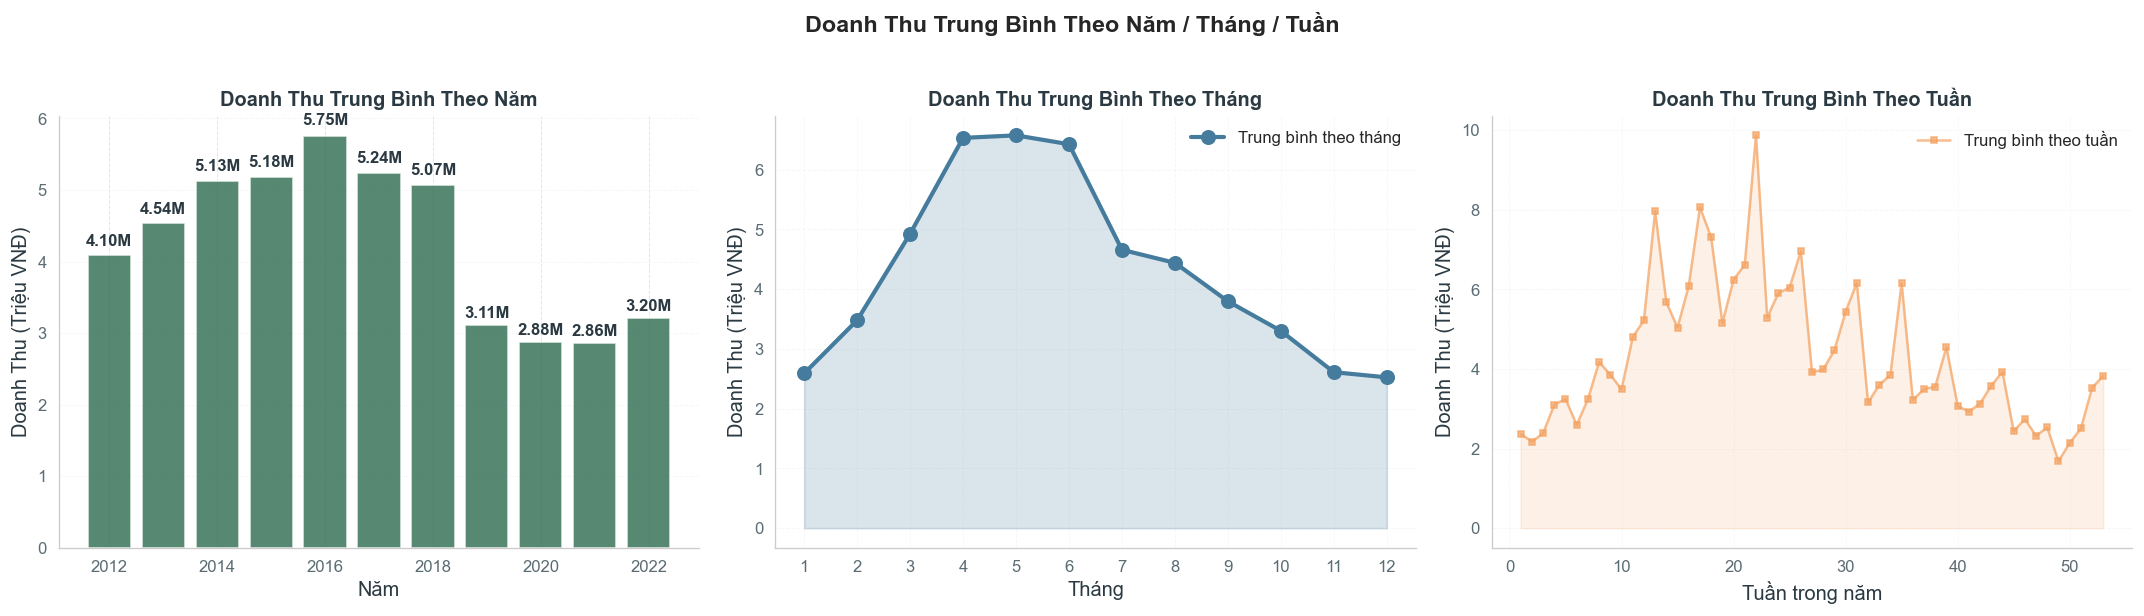

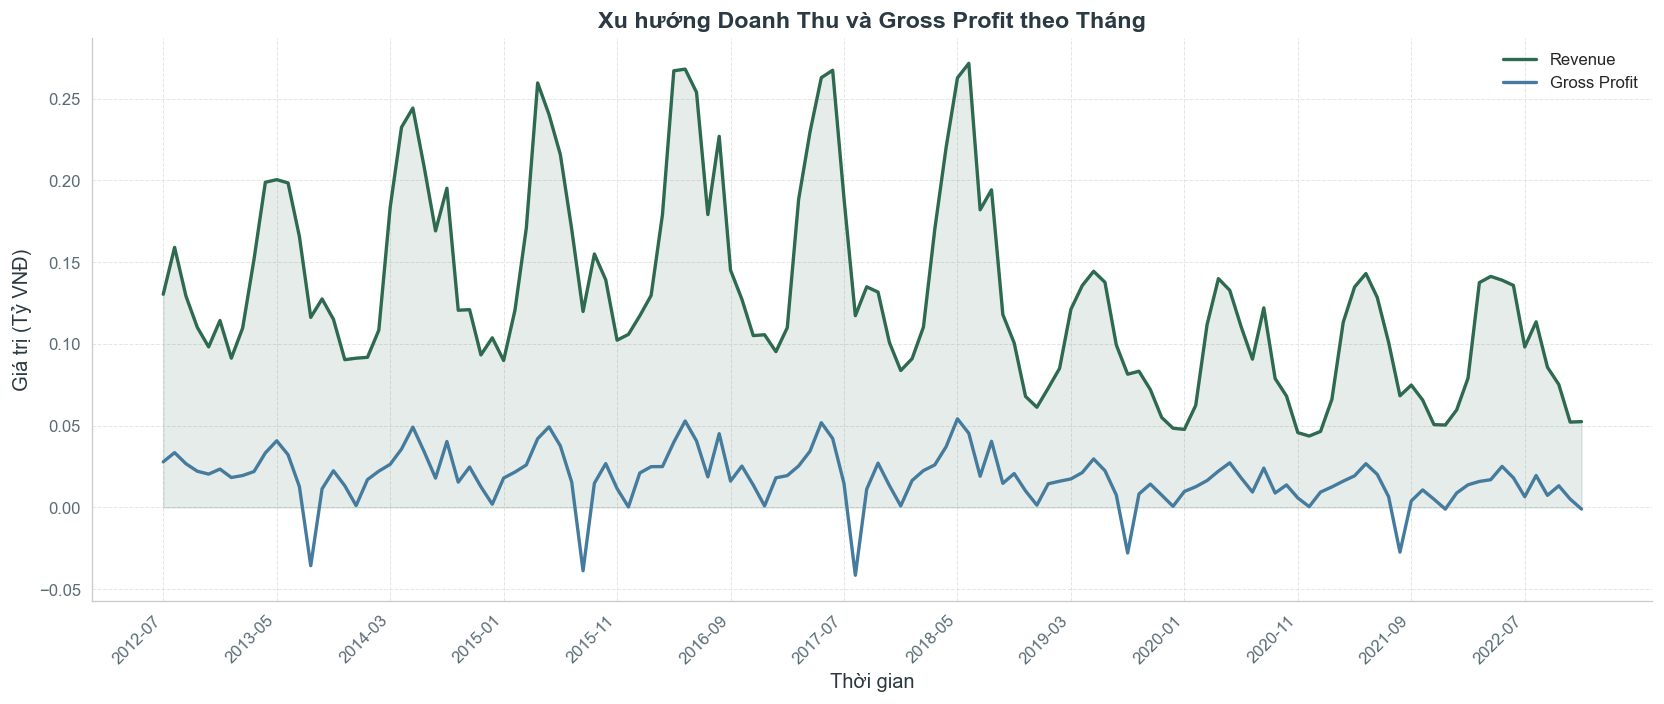

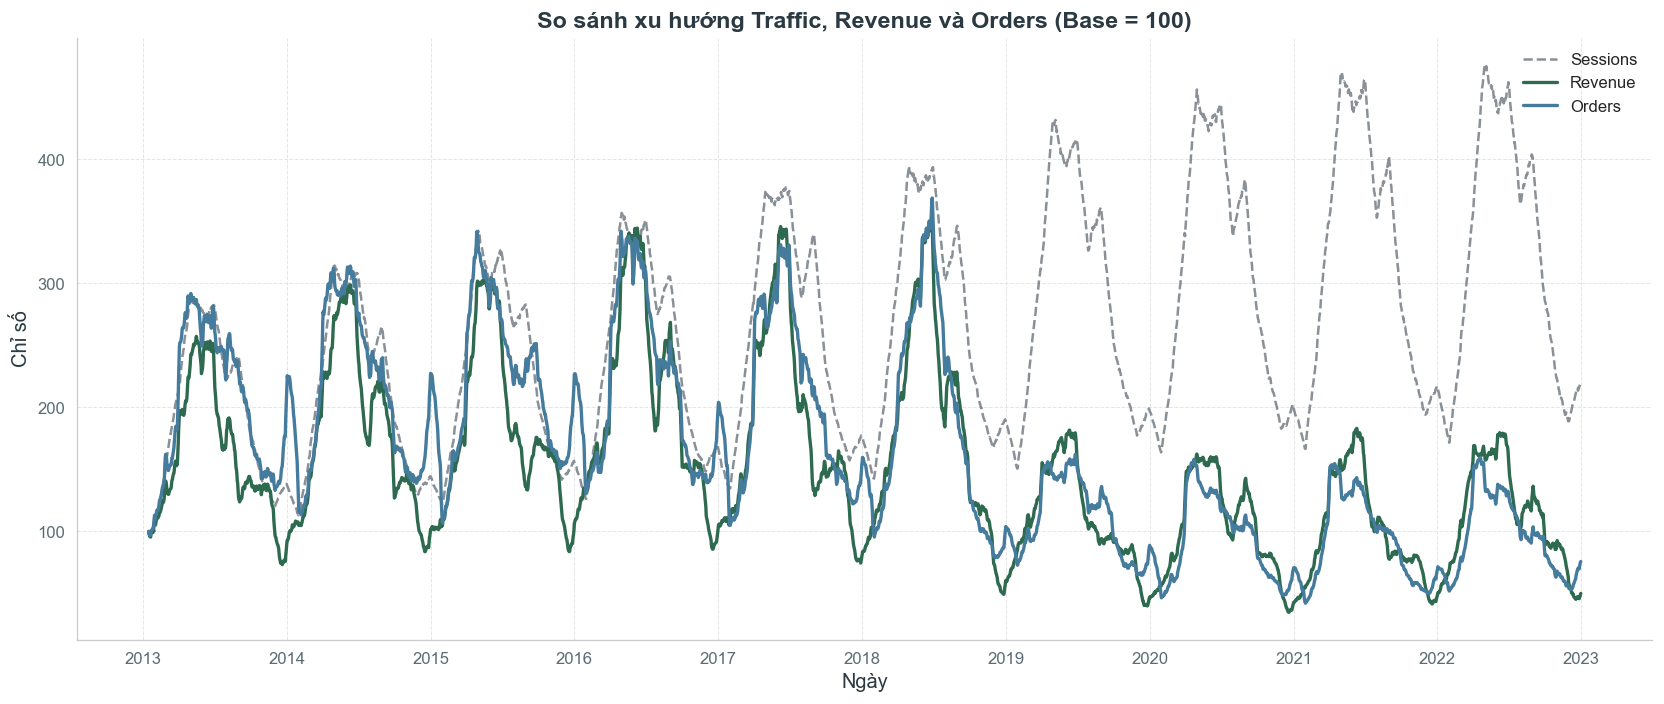

In [17]:
section_header('Trung bình doanh thu theo kỳ hạn và Xu hướng tài chính', 
               'Phân tích doanh thu trung bình theo các kỳ hạn khác nhau và xu hướng tài chính qua thời gian')
plot_revenue_averages_by_period(dfs)
plot_sales_time_series(dfs['sales'])
plot_traffic_revenue_indexed(master_df, dfs['traffic'])

Doanh thu ghi nhận mức tăng trưởng liên tục trong giai đoạn 2014–2018 (CAGR ≈ ...%/năm), trước khi sụt giảm khoảng **40%** ở giai đoạn hậu 2018. Năm 2022 xuất hiện những tín hiệu phục hồi đầu tiên, gợi ý khả năng doanh nghiệp đang dần thích nghi với bối cảnh mới. Biến động này nhiều khả năng chịu ảnh hưởng từ đại dịch Covid-19 và các yếu tố kinh tế vĩ mô.

Một chi tiết đáng chú ý là lượng truy cập (traffic) vẫn duy trì xu hướng tăng ổn định trong suốt giai đoạn này. Điều đó cho thấy vấn đề không nằm ở khả năng thu hút khách hàng, mà tập trung ở hiệu suất chuyển đổi từ traffic thành doanh thu — một điểm nghẽn cần được chẩn đoán sâu hơn. Ở góc độ lợi nhuận, biên lợi nhuận gộp không vượt quá ngưỡng 55 triệu VNĐ/tháng và có những tháng rơi xuống mức âm — tức doanh thu không đủ bù đắp giá vốn hàng bán. Đây là dấu hiệu rõ ràng của một mô hình vận hành dễ tổn thương trước biến động chi phí, với các nguyên nhân tiềm ẩn bao gồm khuyến mãi quá mức, giá vốn tăng cao, hoặc áp lực xả hàng tồn dưới giá vốn.

Về tính mùa vụ, đỉnh doanh thu năm rơi vào quý II (tháng 4–6, tương ứng tuần 17–22) — giai đoạn vàng cần ưu tiên tăng cường tồn kho và đẩy mạnh marketing. Ngược lại, đáy năm xuất hiện ở đầu năm (tháng 1–2) và cuối năm (tháng 11–12), đặc biệt thấp ở các tuần 1–4 và 50–52, cho thấy nhu cầu kích cầu có mục tiêu trong các giai đoạn này để san bằng đường cong doanh thu.

---

### Tóm tắt & Các vấn đề Xác định

 
Với bức tranh tổng quan về doanh nghiệp, chúng ta có cái nhìn rõ hơn về xu hướng doanh thu, bên cạnh đó đồng thời cũng nhận thấy một số thách thức về doanh thu trong giai đoạn gần đây, cũng như các vấn đề về khách hàng và sản phẩm. Điều này đặt ra câu hỏi về nguyên nhân của những xu hướng này, cũng như các chiến lược tiềm năng để cải thiện tình hình kinh doanh trong tương lai. Chúng ta xác định được các vấn đề cần được giải quyết:
- Tỷ lệ huỷ đơn lên tới **9.2%**, và hoàn hàng chiếm **5.8%** tổng số đơn hàng, cho thấy có vấn đề về chất lượng sản phẩm hoặc dịch vụ khách hàng cần được cải thiện.
- Tỷ lệ thiếu hàng và dư thừa hàng tồn kho cao cho thấy có vấn đề trong quản lý chuỗi cung ứng, cũng như về dự báo nhu cầu và quản lý tồn kho.
- Tỷ lệ khuyến mãi lên tới 38.7% nhưng biên lợi nhuận gộp chỉ đạt ở mức 9.7% cho tổng thể 10 năm kinh doanh của doanh nghiệp, cho thấy có vấn đề về chiến lược giá cả và hiệu quả của các chương trình khuyến mãi.
- Ngoài những vấn đề trên ta còn có thể xem xét thêm các vấn đề về tỷ lệ giữ chân khách của doanh nghiệp như thế nào trong 10 năm, qua đó có thể đưa ra các chiến lược để cải thiện tỷ lệ giữ chân khách hàng, cũng như các chiến lược để thu hút khách hàng mới nhằm tăng trưởng doanh thu trong tương lai.

---

## 2. Rò rỉ doanh thu từ Hủy đơn và Hoàn trả

Phần này phân tích chi tiết nguyên nhân và quy mô tổn thất tài chính từ các đơn hàng bị hủy và trả lại — bao gồm phân tích lý do hoàn hàng theo danh mục và kích cỡ, tác động của phương thức thanh toán đến tỷ lệ hủy đơn, và ước tính thiệt hại dòng tiền thực tế.

### Phân bổ Trạng thái Đơn hàng

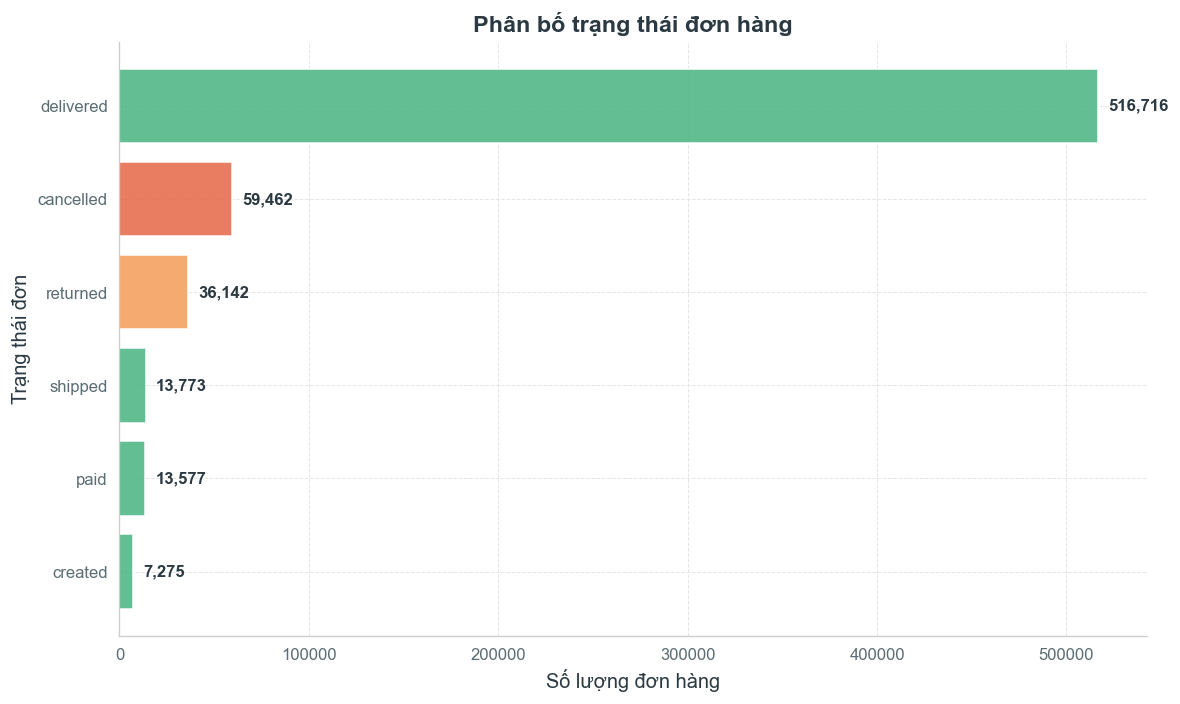

In [18]:
plot_order_status_distribution(dfs['orders'])

### Phân tích Nguyên nhân Hoàn hàng & Hủy đơn

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:1128: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancel_rates = orders.groupby('payment_method').apply(


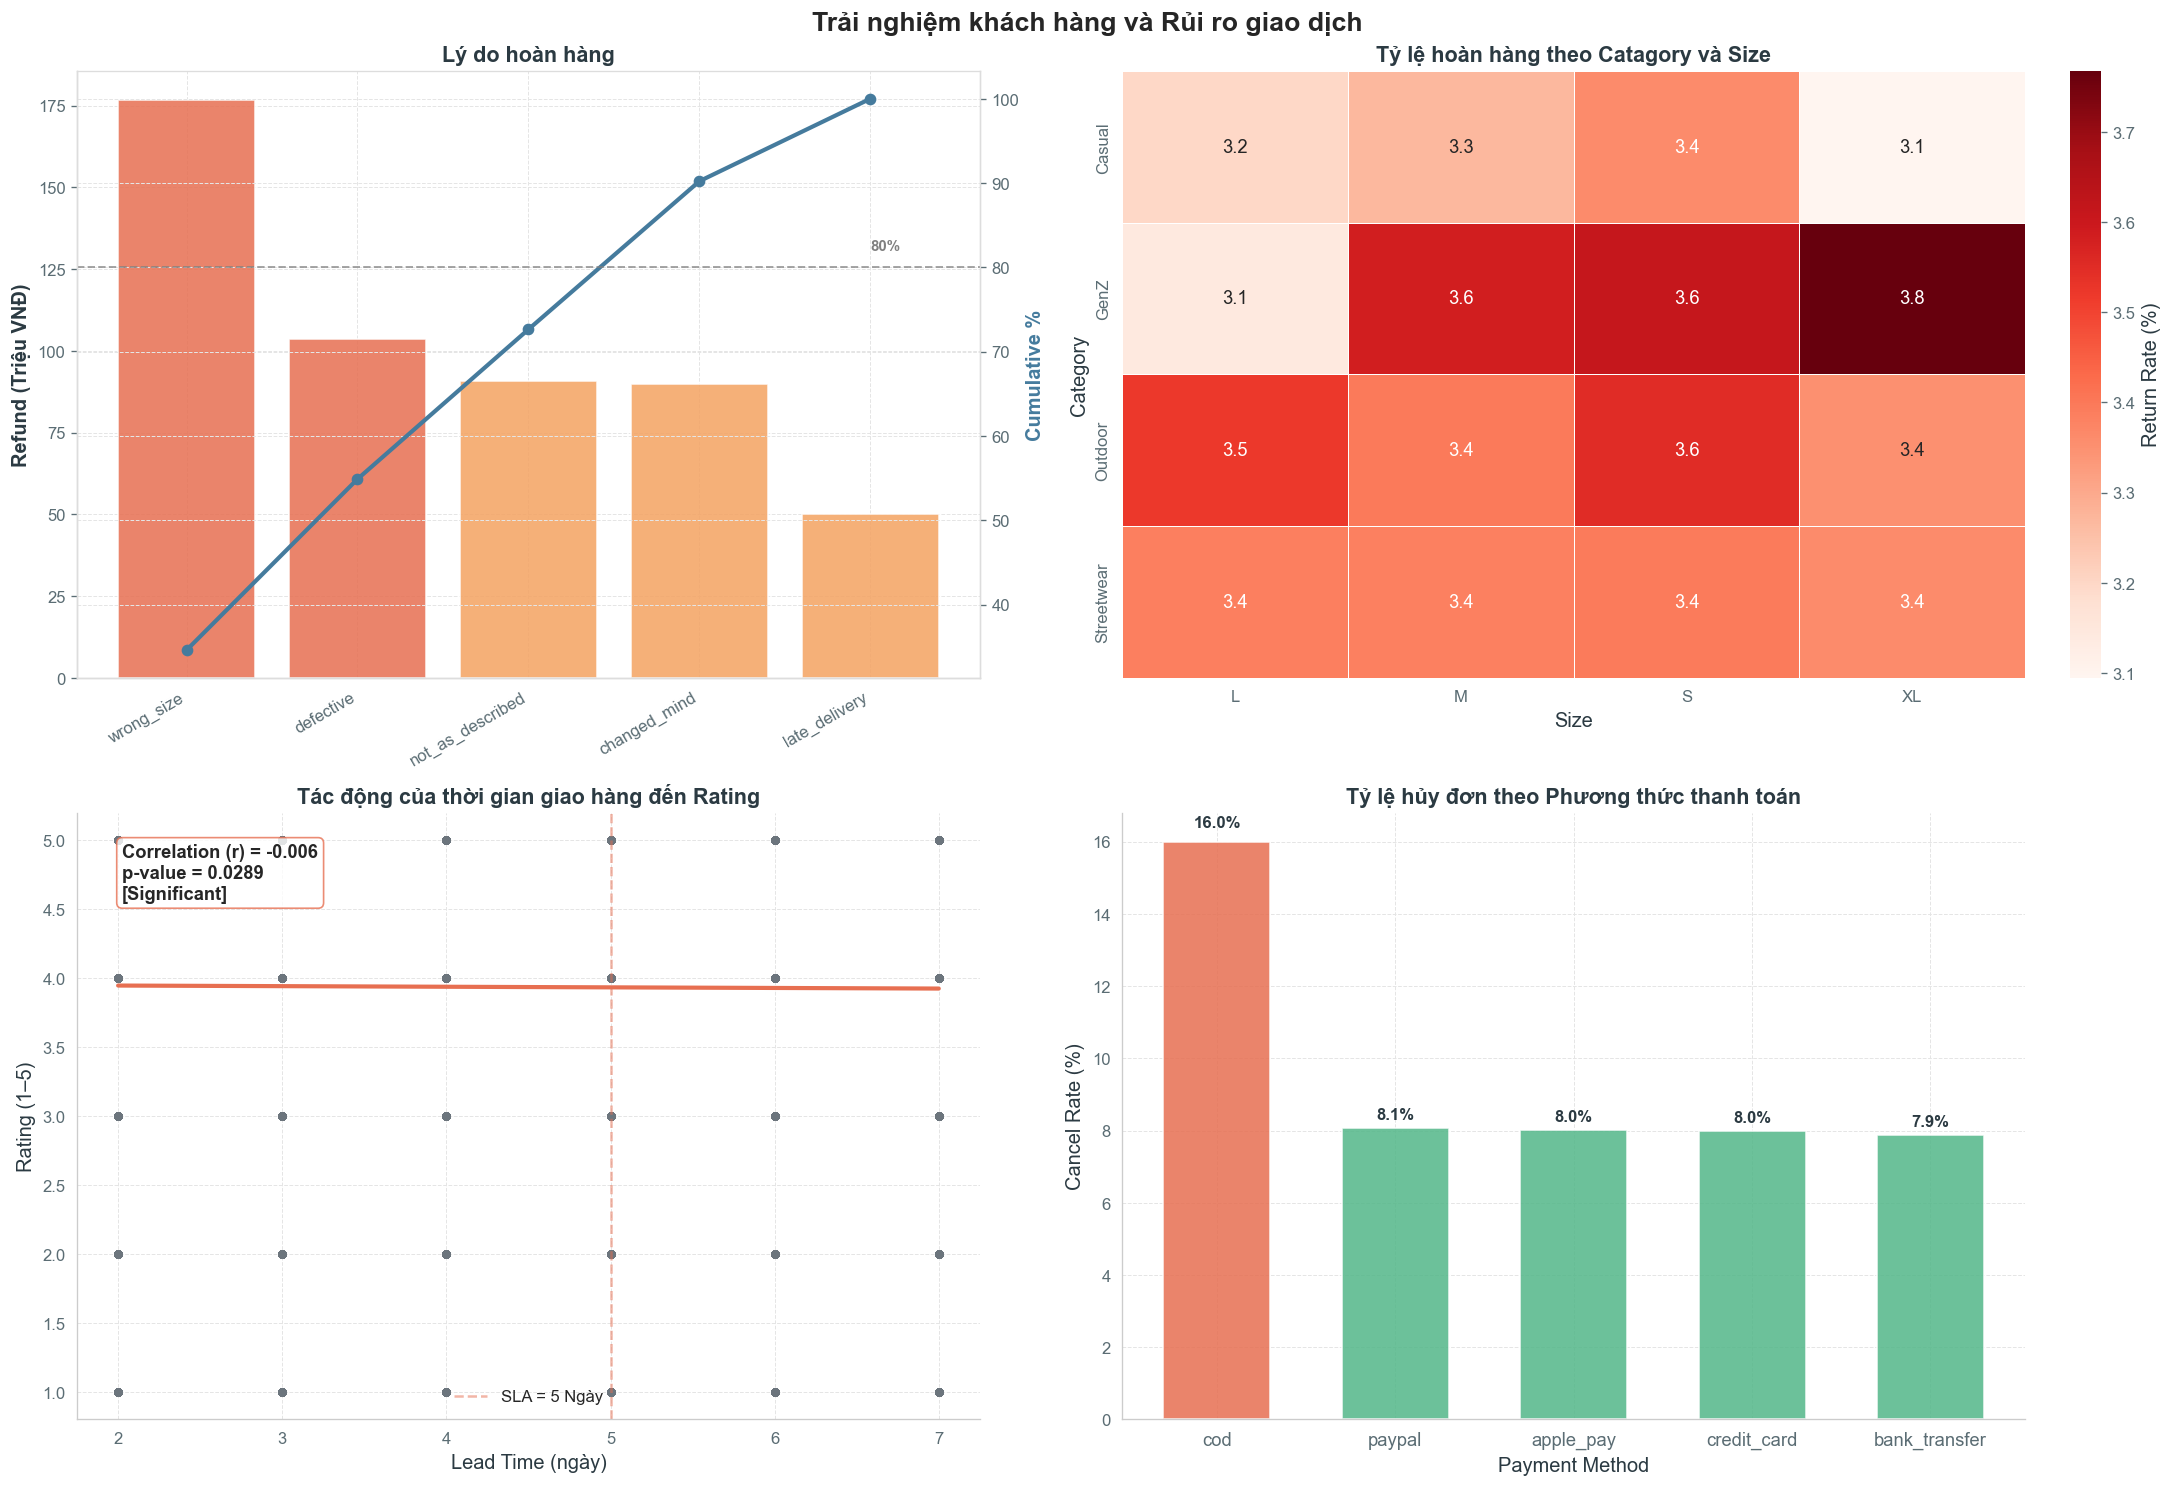

In [19]:
plot_returns_cancellations_deepdive(
    returns=dfs['returns'], 
    products=dfs['products'], 
    order_items=dfs['order_items'], 
    reviews=dfs['reviews'], 
    shipments=dfs['shipments'], 
    orders=dfs['orders'], 
    save_fig=True
)

Hoàn trả và hủy đơn là tổn thất kép: doanh nghiệp không chỉ mất doanh thu mà còn gánh thêm chi phí vận chuyển ngược và đánh mất cơ hội giữ chân khách hàng tiềm năng. Từ bốn góc nhìn phân tích, nổi lên một số quan sát trọng yếu.

**Sai kích cỡ và hàng lỗi là gốc rễ của vấn đề.** Ba nguyên nhân hàng đầu gây ra hơn 70% tổng tổn thất, trong đó `wrong_size` một mình chiếm tới 35%. Cộng thêm `defective`, hai nguyên nhân này đã chiếm gần 55% — chỉ ra rằng vấn đề không nằm ở dịch vụ, mà ở sự phù hợp và chất lượng vật lý của sản phẩm. Giải pháp ở đây là cải thiện bảng hướng dẫn chọn size trên website, bổ sung công cụ gợi ý kích cỡ theo số đo cơ thể, đồng thời siết chặt khâu kiểm tra chất lượng (QC) trước khi xuất kho.

**Dòng hàng GenZ cần được rà soát ưu tiên.** Tỷ lệ hoàn hàng trung bình dao động 3,1%–3,7%, trong đó dòng GenZ ghi nhận mức cao nhất, đặc biệt ở các size M (3,58%), S (3,61%) và XL (3,76%). Cần rà soát lại form dáng và thông số kỹ thuật của dòng này, đồng thời triển khai tính năng đánh giá kèm ảnh thực tế để người mua sau dễ đối chiếu trước khi đặt hàng.

**Thời gian giao hàng không phải nguyên nhân.** Dữ liệu cho thấy tốc độ giao hàng hầu như không ảnh hưởng đến tỷ lệ hài lòng hay hoàn trả — đây không phải điểm nghẽn cần xử lý ưu tiên.

**COD là phương thức có tỷ lệ hủy đơn cao nhất**, chạm mức **16,0%** — gần gấp đôi so với các nhóm thanh toán trước (Credit Card, Apple Pay, PayPal, Bank Transfer dao động 7,9%–8,0%). Khi không có rào cản tài chính ban đầu, tâm lý thay đổi quyết định hoặc "bom hàng" tăng rõ rệt. Để giảm thiểu rủi ro này, cần khuyến khích khách chuyển sang thanh toán trước thông qua các ưu đãi có mục tiêu như miễn phí vận chuyển hoặc chiết khấu 5%; với đơn COD giá trị lớn, nên cân nhắc bổ sung bước xác nhận qua điện thoại hoặc yêu cầu đặt cọc một phần.

### Định lượng Tổn thất Tài chính

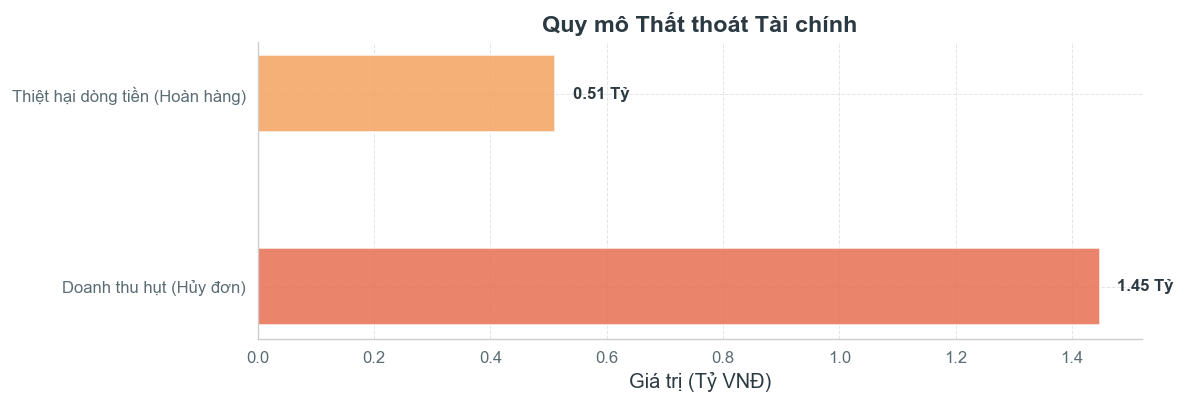

In [20]:
section_header(
    title='Định lượng Tổn thất Tài chính', 
    subtitle='Quy đổi tỷ lệ Hủy đơn và Hoàn hàng thành thiệt hại dòng tiền và chi phí cơ hội thực tế'
)

# Khởi chạy tính toán và lưu kết quả vào biến leakage_metrics
leakage_metrics = plot_revenue_leakage_impact(
    master_df=master_df, 
    returns=dfs['returns'], 
    shipments=dfs['shipments'], 
    save_fig=True
)

Doanh thu bị hủy đơn gây thiệt hại **1,45 tỷ VNĐ** — cao gấp gần 3 lần so với con số **0,51 tỷ VNĐ** từ hoàn hàng. Mặc dù phí vận chuyển lãng phí do hoàn hàng chỉ ở mức 200.000 VNĐ, tổng dòng tiền chảy ngược ra khỏi doanh nghiệp vẫn vượt **500 triệu VNĐ** — bởi mỗi đơn hoàn hàng đã kéo theo toàn bộ chi phí xuất kho, đóng gói, vận chuyển chiều đi lẫn chi phí reverse logistics khi hàng quay về.

Phần lớn trong số 1,45 tỷ VNĐ thất thoát từ hủy đơn xuất phát từ phương thức COD với tỷ lệ hủy đơn lên tới 16%. Việc đặt hàng không có rào cản tài chính ban đầu đã tạo ra một lượng "doanh thu ảo" đáng kể, khiến hệ thống ghi nhận nhu cầu sai lệch và dẫn đến việc giam vốn vào hàng tồn kho không cần thiết.

Để chuyển hóa phần tổn thất này thành doanh thu thực, hai hướng can thiệp trực tiếp bao gồm: áp dụng phí cọc tượng trưng hoặc giới hạn giá trị tối đa cho đơn COD; và chuyển đổi khách sang thanh toán trước bằng mức chiết khấu 2–5% — vẫn thấp hơn tỷ suất lợi nhuận gộp bị lỡ mất — nhằm "khóa" cam kết mua hàng trước khi xử lý đơn.

---

## 3. Stockout, Overstock

Phần này cung cấp cái nhìn toàn diện về sức khỏe tồn kho: xác định nơi tập trung rủi ro thiếu hàng và dư hàng, ước tính doanh thu bị mất do stockout, lượng vốn bị khóa trong overstock, và các kịch bản tài chính khi cải thiện năng lực cung ứng.

### Tổng quan Sức khỏe Tồn kho

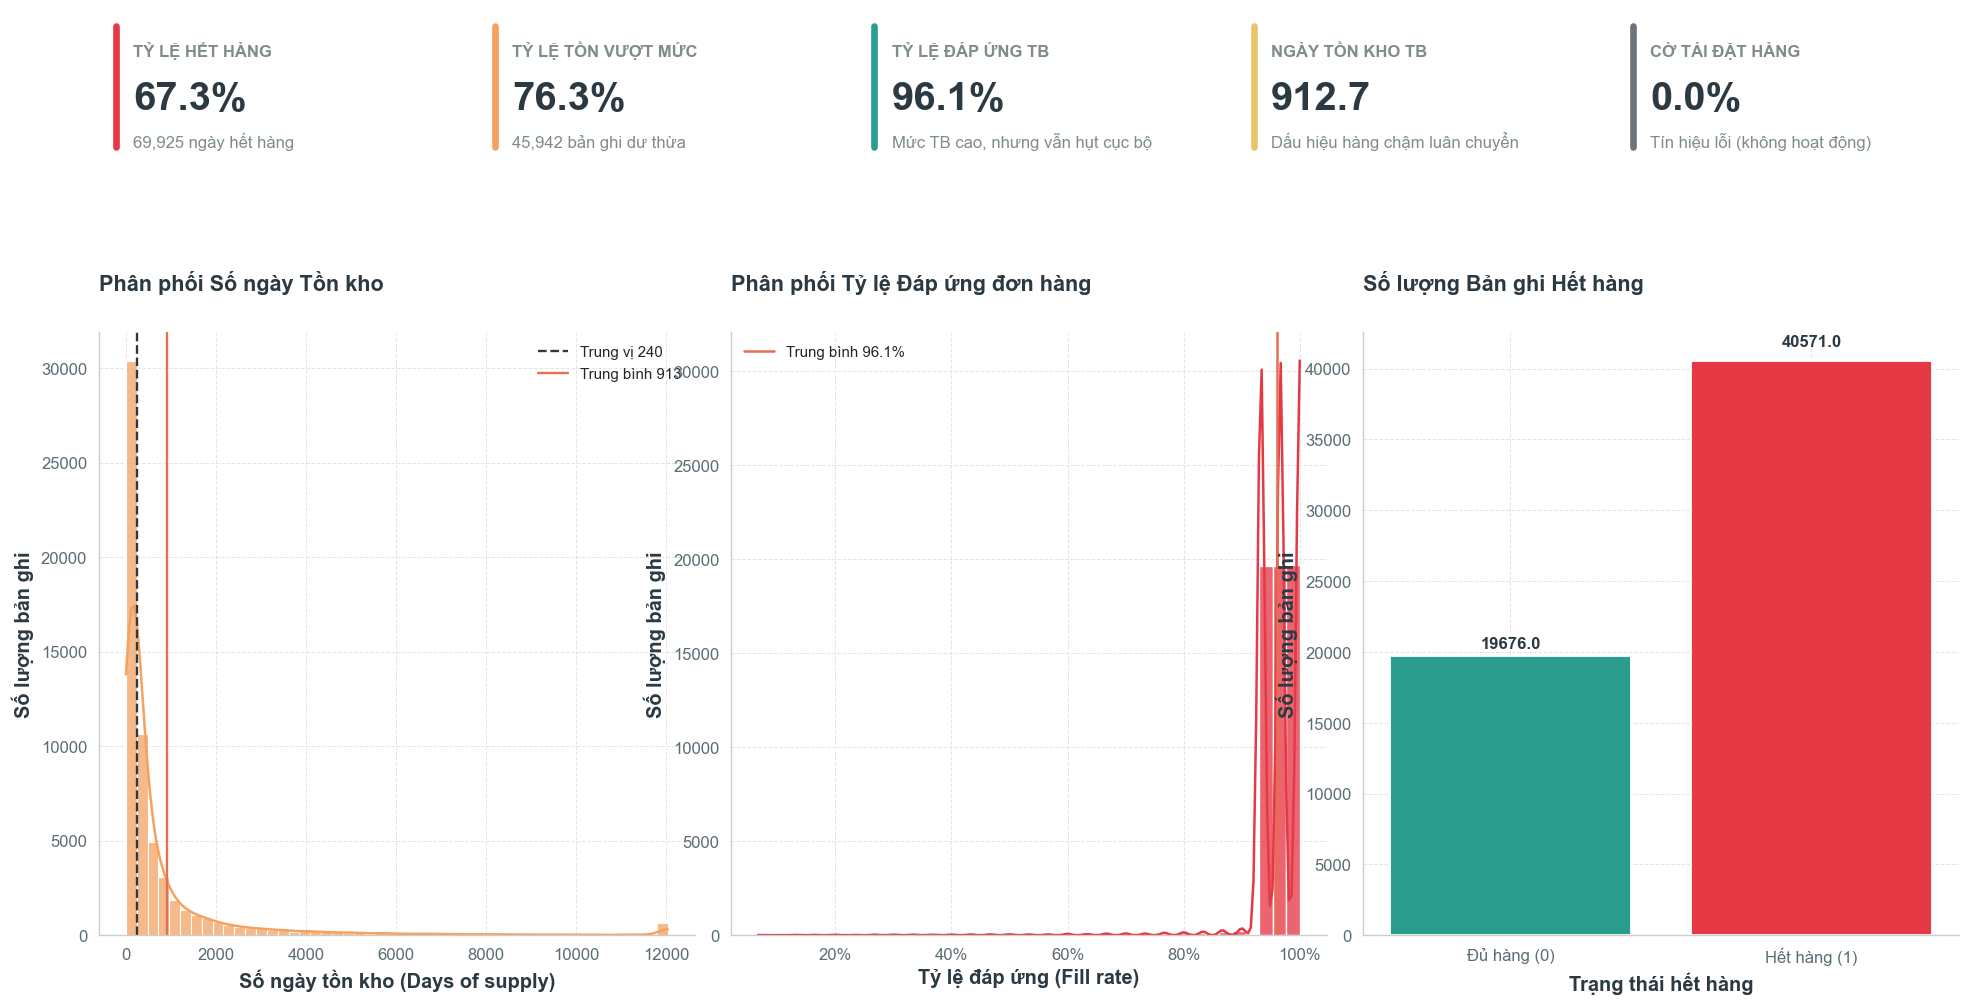

In [21]:
section_header(
    title='Phân tích Vận hành: Sức khỏe Tồn kho', 
    subtitle='Đánh giá rủi ro đứt gãy chuỗi cung ứng và tồn kho dư thừa'
)

# Gọi hàm với dữ liệu inventory
plot_inventory_health_overview(inv=dfs['inventory'], save_fig=True)

Dữ liệu KPI hé lộ một thực tế tưởng như mâu thuẫn: tỷ lệ tháng/phân khúc xảy ra thiếu hàng (stockout) là **67,3%**, trong khi tỷ lệ dư hàng (overstock) cũng chạm mức **76,3%**. Nói cách khác, doanh nghiệp vừa thường xuyên không đủ hàng để bán, vừa có rất nhiều hàng đang nằm im trong kho.

Tuy nhiên, tỷ lệ đáp ứng đơn hàng trung bình vẫn duy trì ở mức cao **96,1%** — cho thấy hệ thống không vận hành kém toàn diện, mà xuất hiện những **điểm đứt gãy cục bộ** theo từng SKU hoặc từng thời điểm cụ thể. Nếu thiếu hàng mang tính hệ thống thật sự, ta kỳ vọng tỷ lệ dư hàng sẽ thấp — nhưng hai chỉ số cùng ở mức cao chỉ ra một bức tranh phức tạp hơn: **hàng có trong hệ thống, chỉ là chưa được đặt đúng nơi và đúng thời điểm cần bán.**

Gốc rễ vấn đề, do đó, không phải là "thiếu hàng" về mặt tổng thể mà là sai phân bổ theo mã sản phẩm và thời điểm — nơi khách cần thì hết, nơi khách không cần thì ứ đọng. Phản ứng phù hợp không phải là nhập thêm hàng đại trà, mà là thiết lập cơ chế theo dõi tồn kho ở **cấp mã sản phẩm × tháng**, từ đó phân loại rõ SKU nào thiếu thật cần bổ sung gấp và SKU nào dư thật cần giảm nhập hoặc xả hàng. Chỉ khi tách bạch được hai nhóm này, doanh nghiệp mới phá vỡ được vòng luẩn quẩn vừa thiếu vừa dư như hiện tại.

### Phân bổ Rủi ro theo Danh mục & Phân khúc

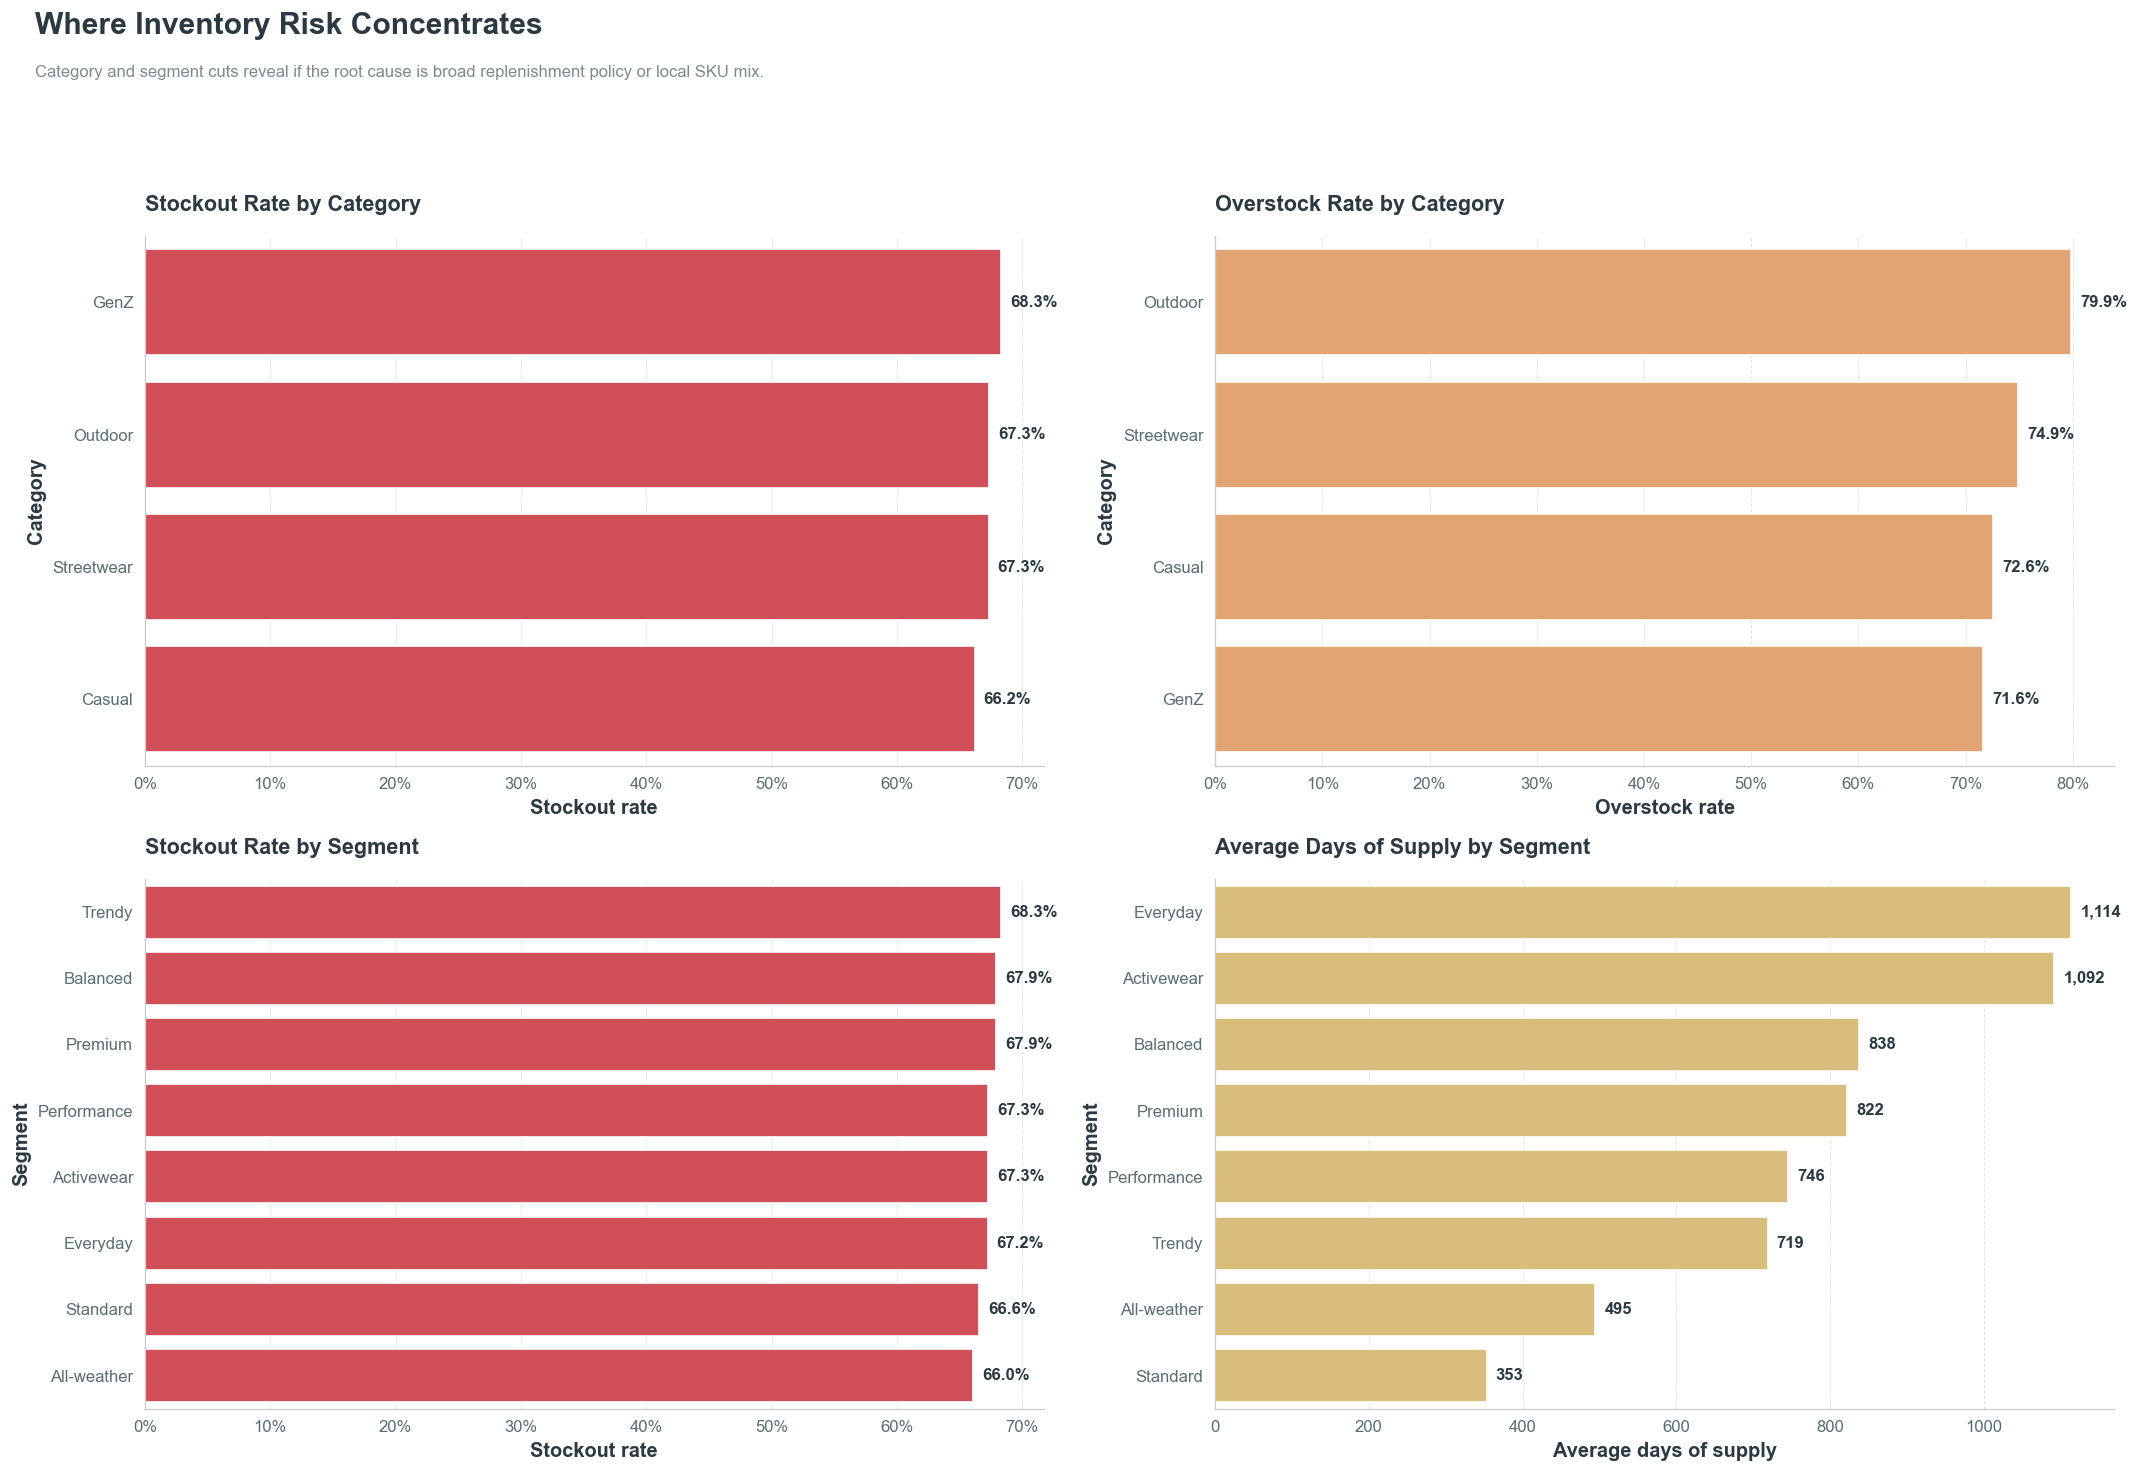

In [22]:
section_header(
    title='Định vị Điểm nghẽn Chuỗi cung ứng', 
    subtitle='Khoanh vùng rủi ro thiếu/thừa hàng hóa theo từng Nhóm và Phân khúc sản phẩm'
)

plot_inventory_risk_concentration(
    inventory=dfs['inventory'], 
    save_fig=True
)

Xét theo danh mục, **GenZ** có tỷ lệ thiếu hàng cao nhất (**68,3%**), nhưng danh mục thấp nhất cũng đã ở mức **66,2%** — chênh lệch chỉ 2,1 điểm phần trăm. Điều này xác nhận rằng stockout là vấn đề trải đều trên toàn danh mục, không phải vấn đề riêng của bất kỳ nhóm hàng cụ thể nào.

Bức tranh thay đổi đáng kể khi nhìn đồng thời cả thiếu hàng lẫn dư hàng. **Outdoor** nổi lên như một điểm nóng nghịch lý: vừa nằm trong nhóm stockout cao, vừa có tỷ lệ overstock cao nhất toàn danh mục — lên đến **79,9%**. Đây là tín hiệu cảnh báo về sai cơ cấu hàng tồn kho trong nội bộ danh mục này, không đơn thuần là chuyện bán chậm hay hết hàng. Ở cấp phân khúc, **Everyday** và **Activewear** ghi nhận số ngày tồn kho trung bình (days of supply) rất cao, cho thấy một phần vốn đáng kể đang bị kẹt ở nhóm hàng quay vòng chậm.

Khuyến nghị hành động là chuyển từ quản lý ở cấp danh mục xuống cấp SKU. Với **Outdoor** và các phân khúc có days of supply cao, cần phân biệt rõ mã nào thực sự cần bổ sung hàng gấp và mã nào cần giảm nhập hoặc lên kế hoạch xả hàng. **Outdoor và các phân khúc tồn kho lâu là nơi cần ưu tiên chẩn đoán trước** — bởi đây là những điểm hội tụ đủ cả hai rủi ro: mất doanh thu và kẹt vốn.

### Phương pháp Ước tính Thiệt hại Stockout

---

Phần ước tính thiệt hại stockout sử dụng phương pháp **Naive Linear Estimate** — giả định sức mua trong những ngày hết hàng hoàn toàn tương đương với những ngày có hàng. Đây là ước lượng cơ bản nhưng đủ mạnh để cung cấp bức tranh tài chính về chi phí cơ hội của việc quản trị tồn kho kém hiệu quả.

Cụ thể, doanh thu bán hàng trung bình ngày được tính theo công thức $\text{avg\_daily\_revenue} = \frac{\text{units\_sold} \times \text{price}}{30}$, từ đó nhân với số ngày hết hàng để ra tổng doanh thu bị lỡ mất: $\text{lost\_revenue\_est} = \text{stockout\_days} \times \text{avg\_daily\_revenue}$. Để báo cáo sắc bén hơn, lợi nhuận gộp thực sự bị mất cũng được tính bằng cách nhân doanh thu thất thoát với biên lợi nhuận gộp tương ứng của từng sản phẩm: $\text{lost\_margin\_est} = \text{lost\_revenue\_est} \times \frac{\text{price} - \text{cogs}}{\text{price}}$.

### Thiệt hại Doanh thu do Thiếu hàng

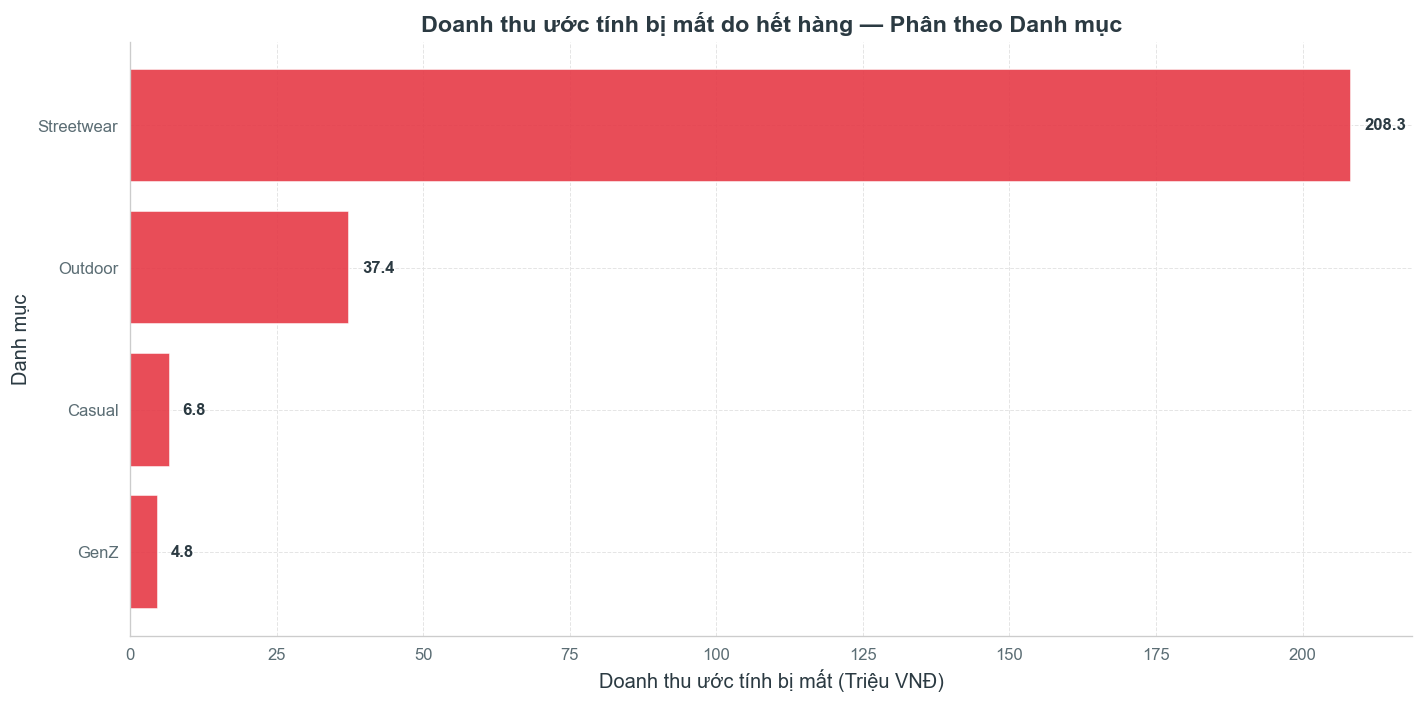

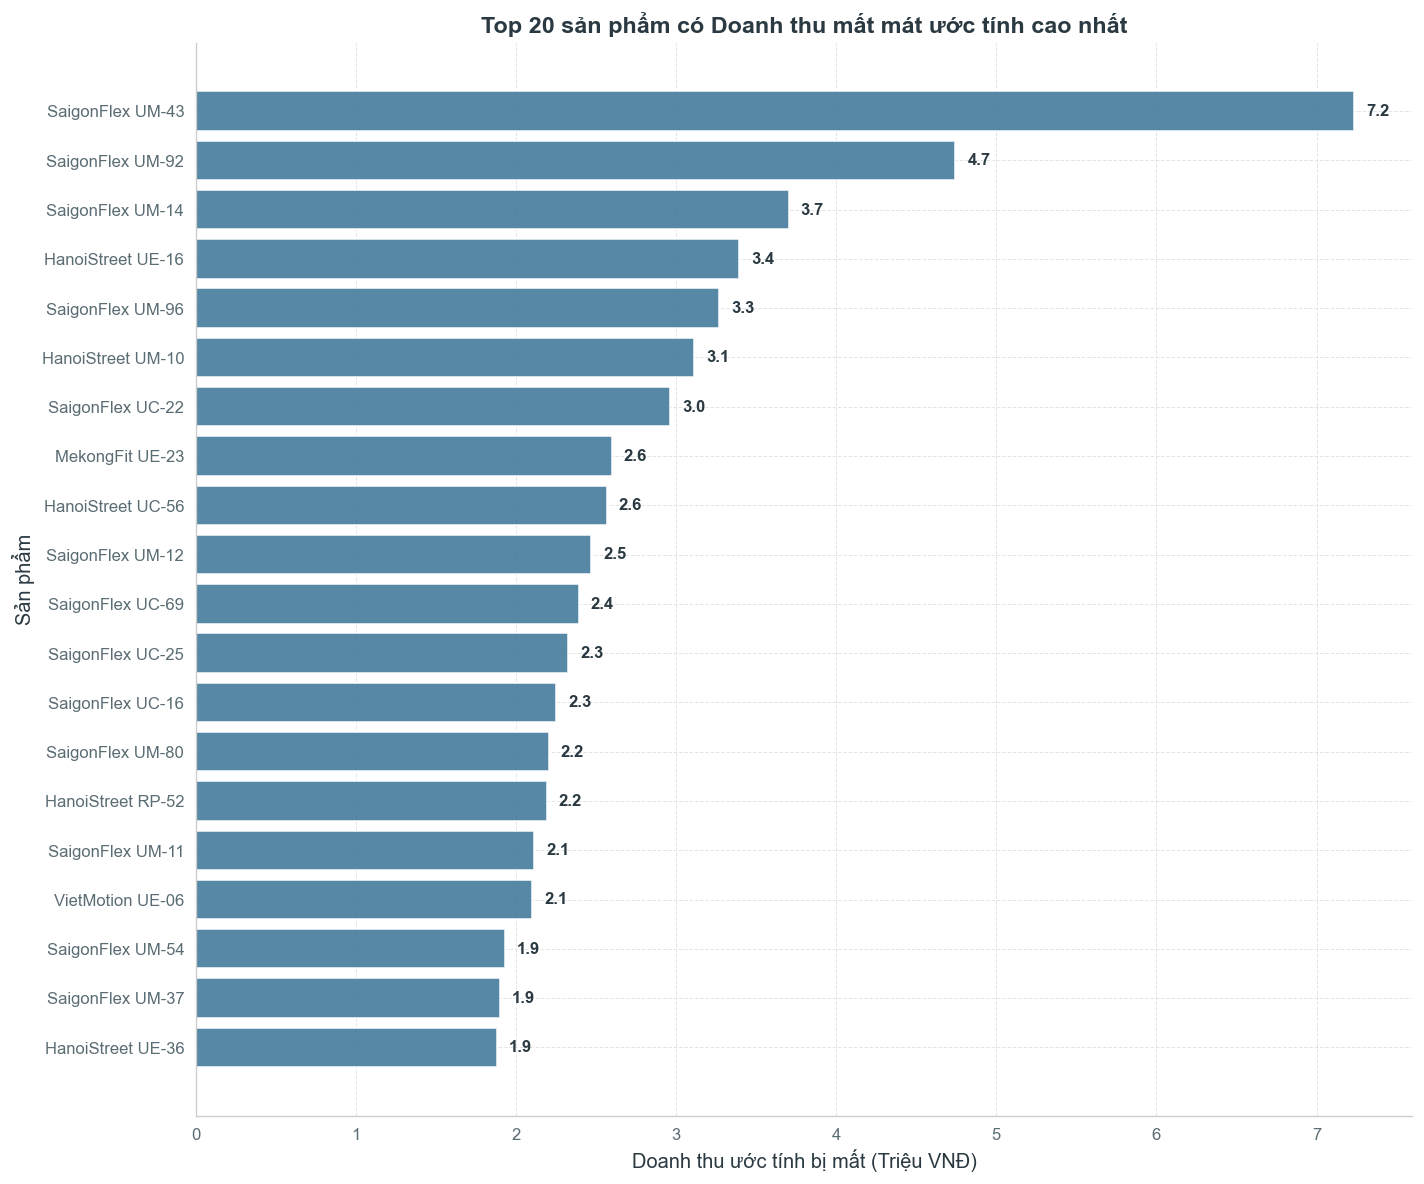

In [23]:
section_header('Impact của stockout', 'Ước tính thiệt hại doanh thu do hàng hết kệ')
stockout_loss_df = estimate_stockout_impact(dfs['inventory'], dfs['products'])
plot_stockout_loss_by_category(stockout_loss_df)
plot_top_products_lost_revenue(stockout_loss_df, top_n=20)

Ước tính cho thấy tình trạng hết hàng đã khiến doanh nghiệp mất khoảng **47.047 sản phẩm** lẽ ra được bán, tương đương **257,4 triệu VNĐ doanh thu** và **50,0 triệu VNĐ lợi nhuận gộp** bị bỏ lỡ. Đây là con số đủ lớn để yêu cầu hành động cụ thể.

**Streetwear là điểm nóng cần ưu tiên tuyệt đối.** Danh mục này một mình chiếm tới **80,9% tổng doanh thu bị mất do thiếu hàng**. Với nguồn lực có hạn, tập trung vào Streetwear sẽ mang lại ROI cao nhất thay vì dàn trải nỗ lực cho tất cả danh mục.

Tuy nhiên, không tồn tại một "siêu mã" duy nhất gây ra toàn bộ vấn đề — mã sản phẩm mất doanh thu cao nhất cũng chỉ chiếm 2,8% tổng lost revenue. Điều này đồng nghĩa với việc cần xử lý theo danh sách nhiều mã ưu tiên, không thể kỳ vọng giải quyết dứt điểm chỉ bằng vài sản phẩm đơn lẻ. Hướng tiếp cận khuyến nghị là rà soát toàn bộ chuỗi cung ứng cho **Streetwear**, sau đó xếp hạng các SKU theo ba tiêu chí: doanh thu bị mất → lợi nhuận gộp → tần suất thiếu hàng — và ưu tiên xử lý các mã đứng đầu danh sách này trước.

Nếu chỉ được chọn một điểm khởi đầu, **Streetwear và các SKU Streetwear có lost revenue cao nhất** là nơi mỗi đồng đầu tư vào cải thiện chuỗi cung ứng sẽ sinh lời nhanh nhất.

### Dư hàng và Vốn bị Khóa

---

Nhìn chỉ vào phần doanh thu bị mất do thiếu hàng, người ta dễ kết luận rằng giải pháp là nhập thêm hàng — nhưng điều đó bỏ qua một rủi ro song song đang hiện diện: tình trạng dư hàng và vốn bị khóa trong kho.

Trong ngành thời trang, vốn nằm trong kho không chỉ là chi phí cơ hội so với các khoản đầu tư hiệu quả hơn, mà còn mang theo rủi ro lỗi mùa, lỗi xu hướng và áp lực phải xả hàng dưới giá vốn. Phần này định lượng chính xác: **bao nhiêu tiền vốn đang bị khóa trong hàng tồn dư** — để việc ra quyết định về nhập hàng được thực hiện với đầy đủ bức tranh, thay vì chỉ nhìn một chiều.

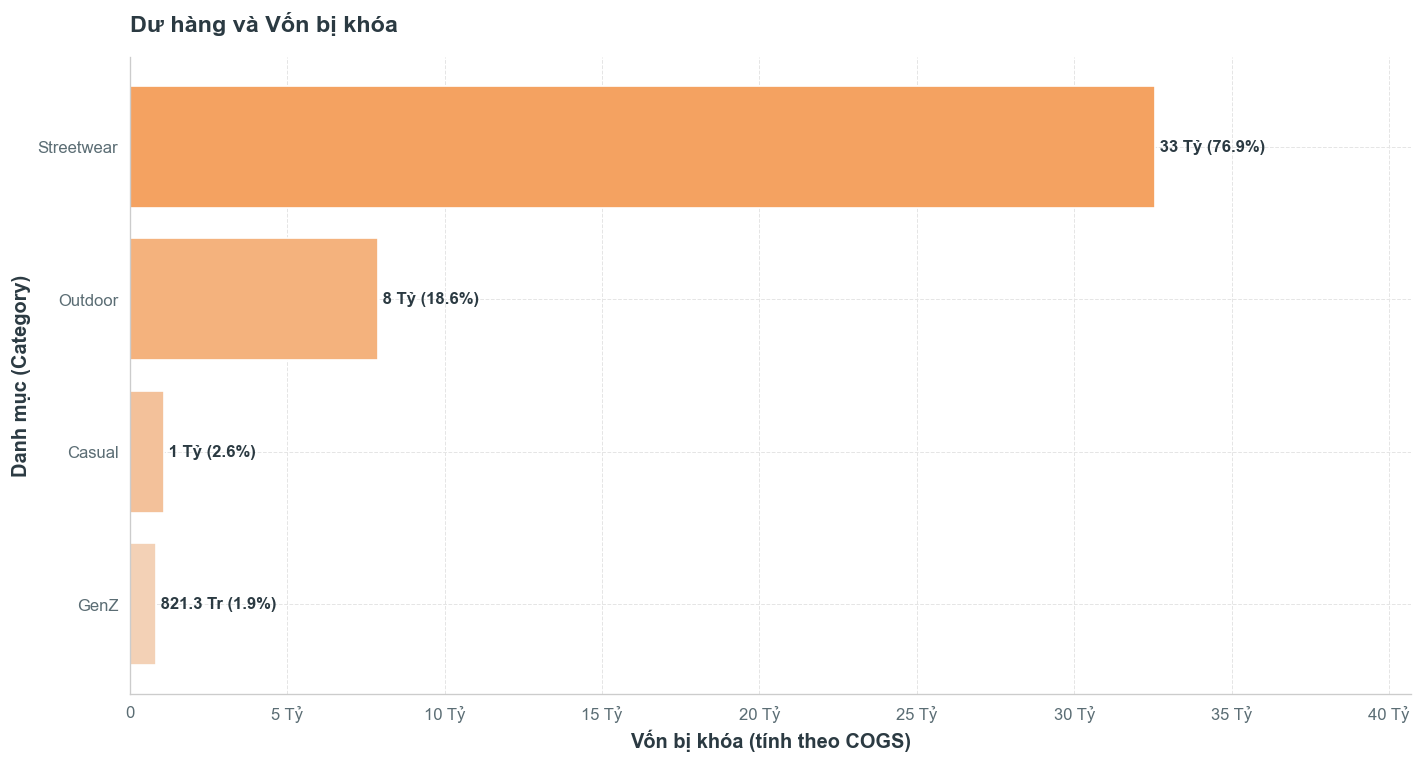

In [24]:
section_header(
    title='Phân tích Rủi ro: Dư hàng và Vốn bị khóa', 
    subtitle='Định lượng rủi ro kẹt vốn theo từng Category để điều chỉnh chiến lược nhập hàng'
)

# Cần truyền vào cả dfs['inventory'] và dfs['products'] để tính toán COGS
plot_overstock_capital_locked(inventory=dfs['inventory'], products=dfs['products'], save_fig=True)

Dữ liệu cho thấy các bản ghi dư hàng đang khóa khoảng **42.339,4 triệu VNĐ** tính theo giá vốn. Riêng **Streetwear** chiếm tới **32.552,2 triệu VNĐ** — tương đương **76,9%** tổng vốn bị kẹt trong hàng tồn dư.

Kết hợp với phát hiện trước đó — Streetwear cũng là nhóm mất doanh thu lớn nhất do thiếu hàng (80,9% tổng lost revenue) — bức tranh trở nên rõ ràng: **Streetwear vừa là nơi chảy máu doanh thu vì thiếu hàng, vừa là nơi chôn vốn nhiều nhất vì dư hàng.** Nhìn bề mặt, điều này có vẻ mâu thuẫn — nhưng đây là dấu hiệu kinh điển của sai cơ cấu tồn kho: những mã khách cần thì không đủ, trong khi những mã khách không mua lại chất đầy kho.

Hệ quả là tuyệt đối không nên nhập thêm Streetwear một cách đại trà. Thay vào đó, cần phân loại từng SKU trong danh mục thành hai nhóm rõ rệt: mã bán chạy, tần suất thiếu hàng cao cần được ưu tiên bổ sung và rút ngắn chu kỳ đặt hàng; mã dư kho lâu ngày, vòng quay thấp cần giảm nhập hoặc dừng nhập và chủ động xả hàng qua bundle, markdown hoặc các chương trình khuyến mãi có mục tiêu. Vấn đề của Streetwear không phải là "cần nhiều hàng hơn", mà là **cần đúng hàng hơn**.

### Kịch bản Thu hồi Doanh thu

Phần này sử dụng cách tính tuyến tính đơn giản để minh họa quy mô cơ hội tài chính khi cải thiện tỷ lệ thiếu hàng. Cần lưu ý đây là **ước tính tuyến tính**, không phải forecast — giảm thiếu hàng 20% không tự động đồng nghĩa thu hồi 20% doanh thu bị mất, do một phần khách hàng có thể đã mua sản phẩm thay thế, rời đi, hoặc nhu cầu đã mất vĩnh viễn.

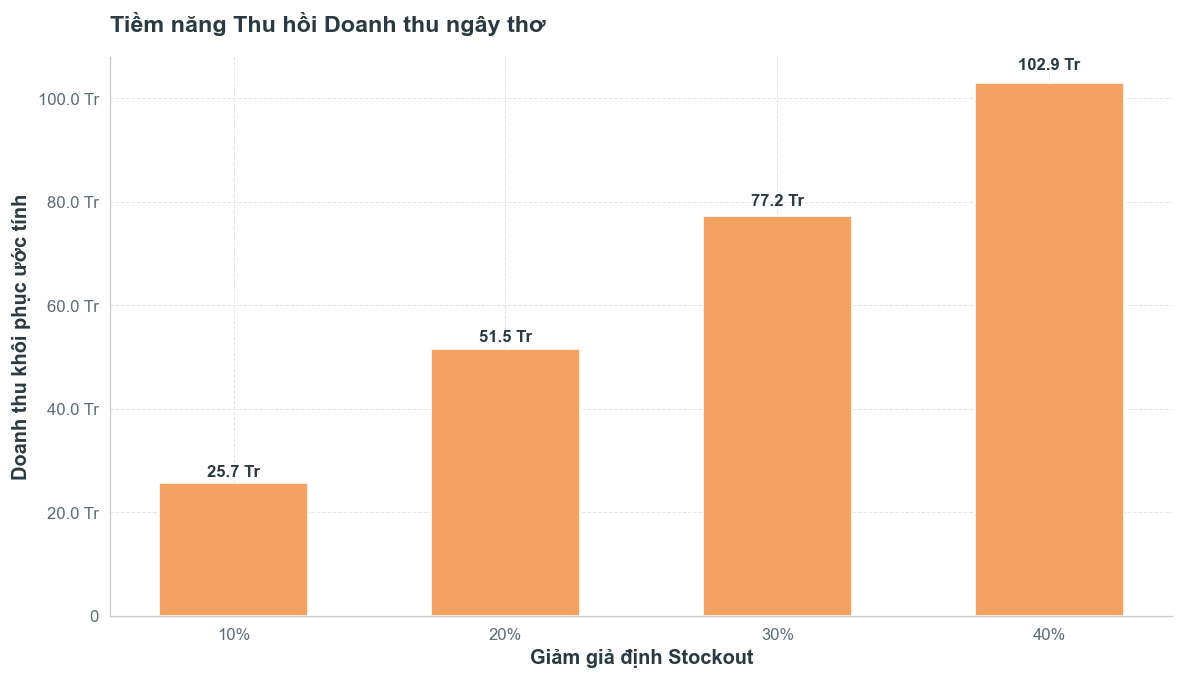

,Mức giảm stockout giả định,Recovered revenue estimate,Recovered gross margin estimate
0,0.1,2.573517e+07,5.000518e+06
1,0.2,5.147033e+07,1.000104e+07
2,0.3,7.720550e+07,1.500155e+07
3,0.4,1.029407e+08,2.000207e+07


In [25]:
section_header(
    title='Dự phóng Kinh doanh: Tiềm năng Thu hồi Doanh thu', 
    subtitle='Ước tính quy mô dòng tiền thu hồi được khi cải thiện năng lực cung ứng (Giảm Stockout)'
)

# Chạy mô hình giả định và lưu biểu đồ
recovery_scenario_df = plot_stockout_recovery_scenarios(
    inventory=dfs['inventory'], 
    products=dfs['products'], 
    save_fig=True
)

# Hiển thị bảng số liệu chi tiết để xem thêm phần Gross Margin
display(recovery_scenario_df)

Phân tích kịch bản cho thấy tiềm năng tài chính đáng kể: giảm **20%** tỷ lệ thiếu hàng có thể mang lại khoảng **51,5 triệu VNĐ doanh thu** và **10,0 triệu VNĐ lợi nhuận gộp**; ở kịch bản tham vọng hơn với mức giảm **40%** stockout, con số doanh thu phục hồi ước tính lên tới **102,9 triệu VNĐ**.

Tuy nhiên, cần tránh một bẫy tư duy phổ biến: **giảm thiếu hàng bằng mọi giá không đồng nghĩa với tăng lợi nhuận.** Nếu kéo tỷ lệ stockout xuống bằng cách nhập thêm hàng ồ ạt, chi phí lưu kho tăng vọt hoặc tạo ra làn sóng dư hàng mới sẽ bào mòn toàn bộ lợi nhuận phục hồi — thậm chí đẩy kết quả về mức âm.

Lộ trình khuyến nghị là triển khai theo từng bước: **pilot với kịch bản giảm 20% stockout**, tập trung vào Streetwear — nhóm vừa có lost revenue cao nhất, vừa có dư địa cải thiện cơ cấu tồn kho rõ nhất. Sau pilot, đo lường thực tế lợi nhuận gộp phục hồi so với chi phí tồn kho phát sinh thêm; chỉ mở rộng lên kịch bản 40% hoặc ra các danh mục khác khi bài toán lợi ích-chi phí xác nhận hiệu quả dương. **Đừng đổi vấn đề thiếu hàng lấy vấn đề dư hàng.**

### **Cross-table Checks: Promotion, Traffic, Returns**

Phần này mở rộng góc nhìn phân tích bằng cách kiểm tra mối liên hệ giữa các yếu tố vận hành bên ngoài bảng tồn kho — cụ thể là khuyến mãi, lưu lượng truy cập và tỷ lệ hoàn trả — với các chỉ số stockout và overstock. Mục tiêu không phải chứng minh quan hệ nhân quả tuyệt đối, mà là xác định các tín hiệu tương quan đủ mạnh để định hướng hành động. Ba câu hỏi được đặt ra: liệu tháng có promotion có làm tăng stockout hoặc lost revenue không; liệu tháng traffic cao có trùng với lost revenue cao không; và liệu hàng dư có xuất phát từ tỷ lệ hoàn trả cao không.

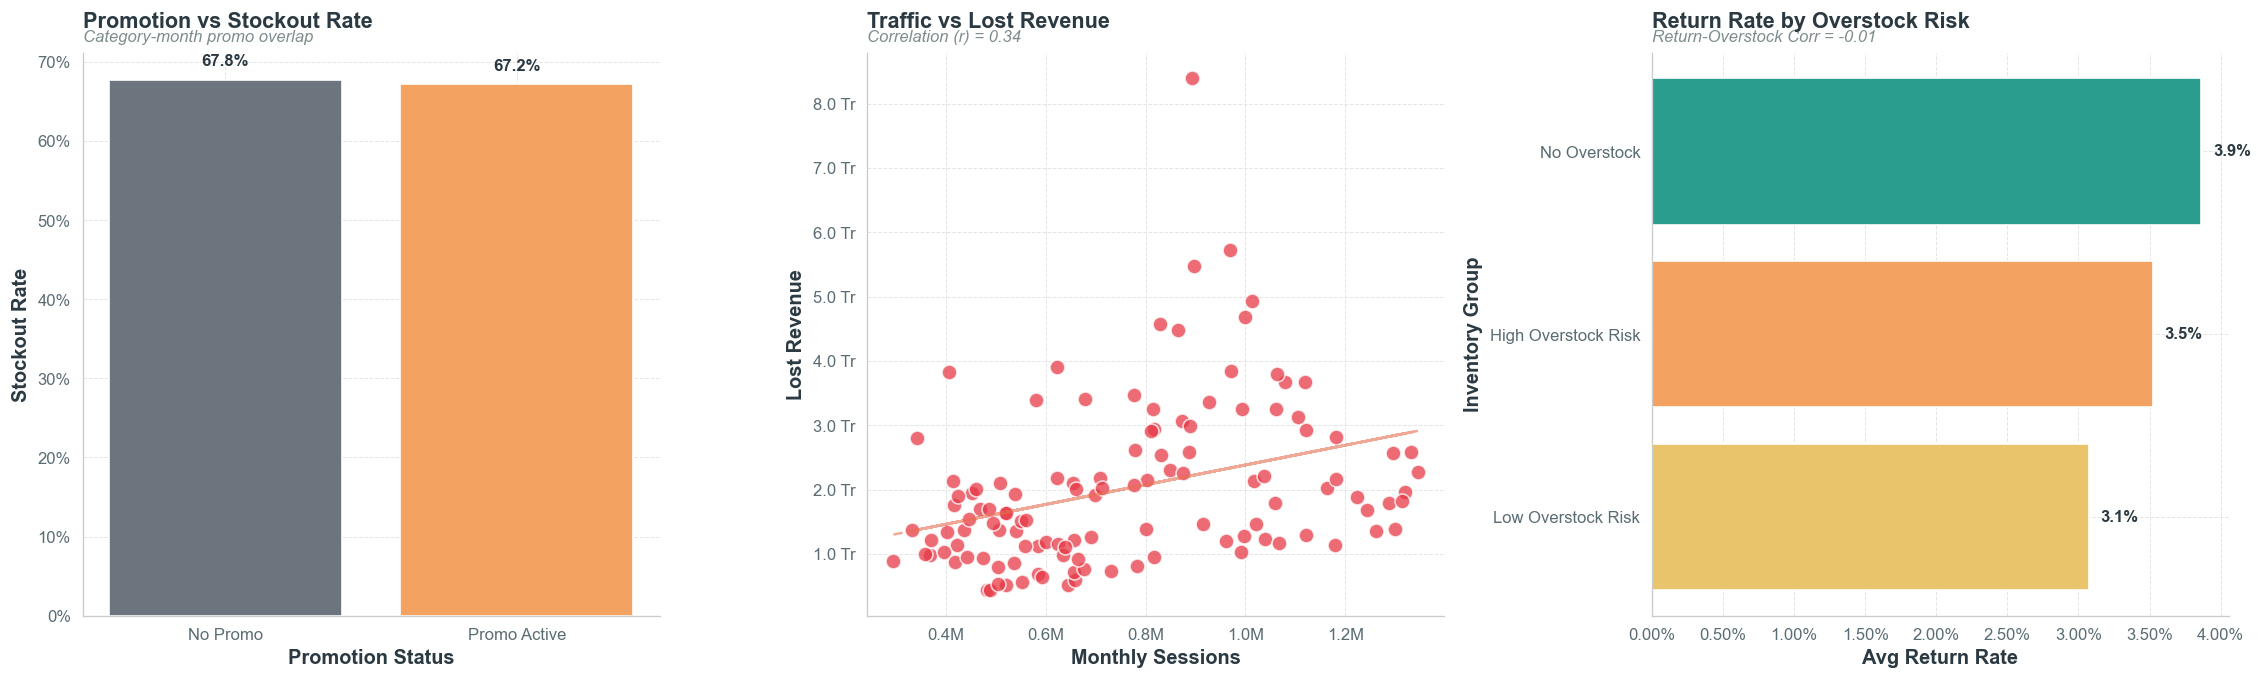

--- Tổng hợp Insight Cross-table ---


,Check,Main metric,Business read
0,Promotion overlap,Promo-active stockout: 67.2%,Use to check campaign inventory readiness.
1,Web traffic overlap,Traffic-lost revenue corr: 0.34,Market-level signal only; traffic is not SKU-l...
2,Returns vs overstock,Return-overstock corr: -0.01,Low correlation means returns are unlikely to ...


In [26]:
section_header(
    title="Cross-table Checks: Promotion, Traffic, Returns",
    subtitle="Kiểm tra mối liên hệ nhân quả tiềm năng giữa các yếu tố vận hành (Promo, Traffic, Returns) đối với Tồn kho."
)

inv_lost = estimate_stockout_impact(dfs['inventory'], dfs['products'])
plot_cross_table_diagnostics(dfs=dfs, inv_lost=inv_lost, save_fig=True)

#### 1. Tháng có Promotion có làm tăng Stockout hoặc Lost Revenue không?

Dữ liệu cho thấy các chiến dịch khuyến mãi **không làm tăng tần suất đứt hàng** — tỷ lệ stockout dao động ngang nhau ở mức 67,7% (không promo) và 67,2% (có promo), cho thấy khâu chuẩn bị hàng hóa cho các chiến dịch cơ bản là có tính toán trước. Tuy nhiên, điểm đáng lo ngại nằm ở quy mô thiệt hại: trong các tháng có chạy promo, tổng doanh thu bị lỡ mất do hết hàng **tăng vọt gấp gần 4 lần** — từ ~55 triệu lên ~202 triệu VNĐ. Điều này cho thấy tuy tần suất đứt hàng không đổi, nhưng vì lượng cầu trong kỳ promo lớn hơn nhiều, mỗi lần cháy hàng gây thiệt hại chi phí cơ hội nặng nề hơn so với ngày thường. Cơ chế phân bổ tồn kho đệm (safety stock) dày hơn riêng cho các sản phẩm chạy promo là điều cần thiết.

#### 2. Tháng Traffic cao có trùng với Lost Revenue cao không?

Hệ số tương quan giữa số sessions và lost revenue đạt **0,3406** — mức tương quan thuận trung bình, cho thấy khi traffic đổ về nhiều, rủi ro mất doanh thu do hết hàng cũng tăng theo. Điều này củng cố thêm nhận định từ phân tích trước: vấn đề không nằm ở việc vận hành chuỗi cung ứng kém đi, mà ở năng lực tồn kho hiện tại chưa đủ sức đáp ứng các đợt tăng vọt traffic từ các kênh marketing.

#### 3. Hàng dư có đến từ việc khách hoàn trả nhiều không?

Đây là một phát hiện mang tính phủ định có giá trị cao. Tỷ lệ hoàn trả ở nhóm không dư hàng (3,86%) và nhóm dư hàng rủi ro cao (3,52%) gần như bằng nhau, với hệ số tương quan giữa return rate và overstock rate chỉ ở mức **-0,0088** — gần bằng không. Dữ liệu này là bằng chứng rõ ràng rằng **hành vi hoàn trả của khách hàng không phải nguyên nhân gây ra tồn kho dư thừa.** Gốc rễ của vấn đề overstock nằm ở khâu dự báo thu mua đã nhập về số lượng vượt quá lực hấp thụ thực tế của thị trường ngay từ đầu.

---

## 4. Khuyến mãi

Phần này kiểm chứng hiệu quả tài chính thực tế của các chương trình khuyến mãi — so sánh biên lợi nhuận giữa đơn hàng có và không có khuyến mãi, bóc tách ảnh hưởng của từng loại mã giảm giá (percentage vs. fixed), và xác định liệu khuyến mãi đang thúc đẩy doanh số hay chỉ đang phá hủy lợi nhuận.

Như đã đề cập, **38,7%** tổng lượng đơn hàng hiện đang phụ thuộc vào các chương trình khuyến mãi — một tỷ lệ rất đáng kể. Câu hỏi đặt ra là liệu quy mô phụ thuộc đó có đang tạo ra giá trị tương xứng hay không.

### So sánh Biên lợi nhuận: Có và Không Khuyến mãi

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:708: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(_margin_percent).rename('margin').reset_index()
/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:715: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(_margin_percent).reset_index(name='margin')


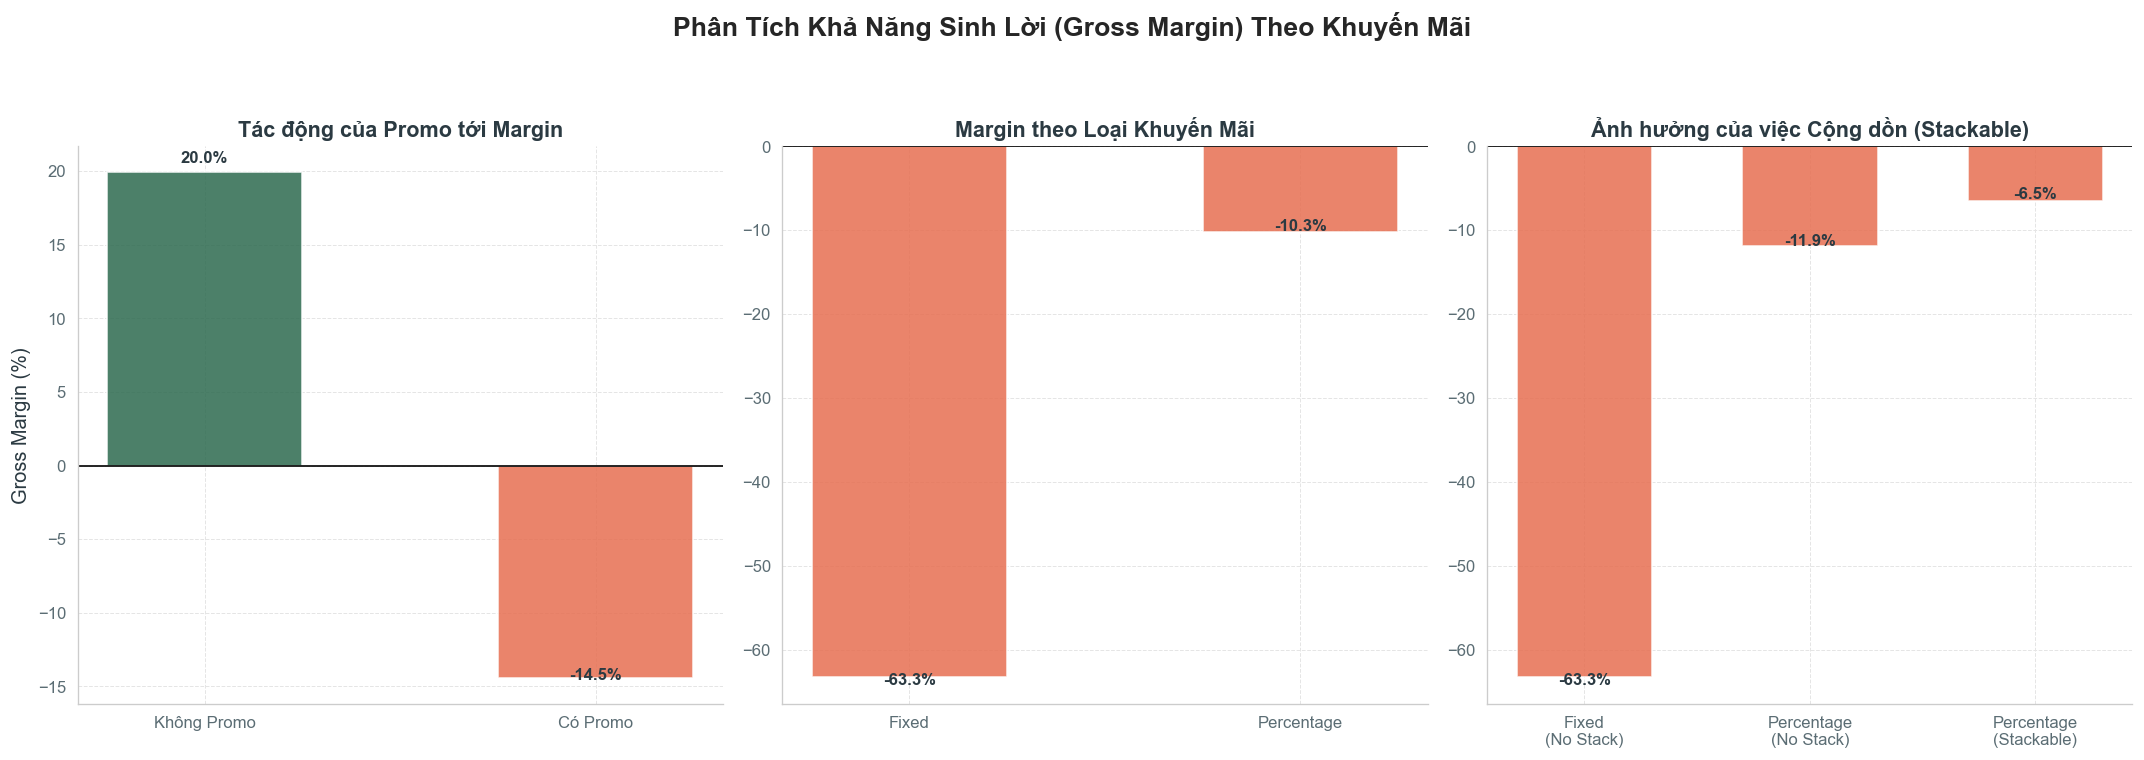

In [27]:
section_header('Phân tích khuyến mãi', 'So sánh biên lợi nhuận giữa đơn hàng có và không có khuyến mãi')
promo_summary = compute_promotion_margins(master_df)
plot_promotion_margins_analysis(promo_summary)

Khi không áp dụng khuyến mãi, doanh nghiệp duy trì biên lợi nhuận gộp ổn định ở mức **20,0%**. Ngay khi có mã khuyến mãi xen vào, biên lợi nhuận lao dốc xuống mức âm **-14,5%** — nói cách khác, doanh nghiệp đang chịu lỗ để khách hàng mua sản phẩm của mình. Đây là một mô hình không bền vững về bản chất.

Khi bóc tách theo loại khuyến mãi, bức tranh càng trở nên nghiêm trọng. Mã giảm theo số tiền cố định (**fixed**) đẩy Gross Margin xuống **-63,3%**, trong khi mã giảm theo phần trăm (**percentage**) ghi nhận mức âm **-10,3%**. Con số -63,3% ở nhóm fixed cho thấy nhiều mã giảm cố định đang được áp dụng cho các đơn hàng có giá trị quá nhỏ, khiến doanh thu thu về không đủ bù đắp giá vốn hàng bán.

Ngay trong nhóm percentage, cấu hình cũng chưa đúng: các mã không cho phép cộng dồn (No Stack) ghi nhận mức âm sâu hơn (**-11,9%**) so với các mã được phép cộng dồn (Stackable, ở mức -6,5%). Điều này cho thấy tỷ lệ giảm giá thiết lập cho các mã đơn lẻ đang vượt quá biên độ lợi nhuận gộp thực tế của sản phẩm — doanh nghiệp đang "over-discount" ngay từ mã đầu tiên, chưa cần cộng dồn đã lỗ.

Hai hành động ưu tiên cần thực hiện ngay: **audit và tạm dừng toàn bộ mã fixed** chưa có điều kiện giá trị đơn hàng tối thiểu (`min_order_value`) đủ lớn để bảo vệ điểm hòa vốn; và **chuyển đổi sang mô hình Tiered Discount** (mua càng nhiều, giảm càng sâu) kết hợp trần giảm giá tối đa (Capped Discount) để kiểm soát biên lợi nhuận. Với 38,7% đơn hàng đang nằm trong vùng khuyến mãi, tiếp tục vận hành các chương trình như hiện tại đồng nghĩa với việc **càng bán nhiều, càng lỗ sâu**.

---

## 5. Tỷ lệ giữ chân khách hàng

Phần này phân tích hành vi và vòng đời khách hàng thông qua mô hình RFM (Recency, Frequency, Monetary), xu hướng churn và retention theo thời gian, mô hình sinh tồn theo phân khúc, và ma trận ưu tiên hành động. Mục tiêu là xác định nhóm khách hàng nào đang tạo ra giá trị, nhóm nào đang rời bỏ, và can thiệp nào là cần thiết để bảo vệ tệp khách hàng dài hạn.

### Phân tích RFM & Vòng đời Khách hàng

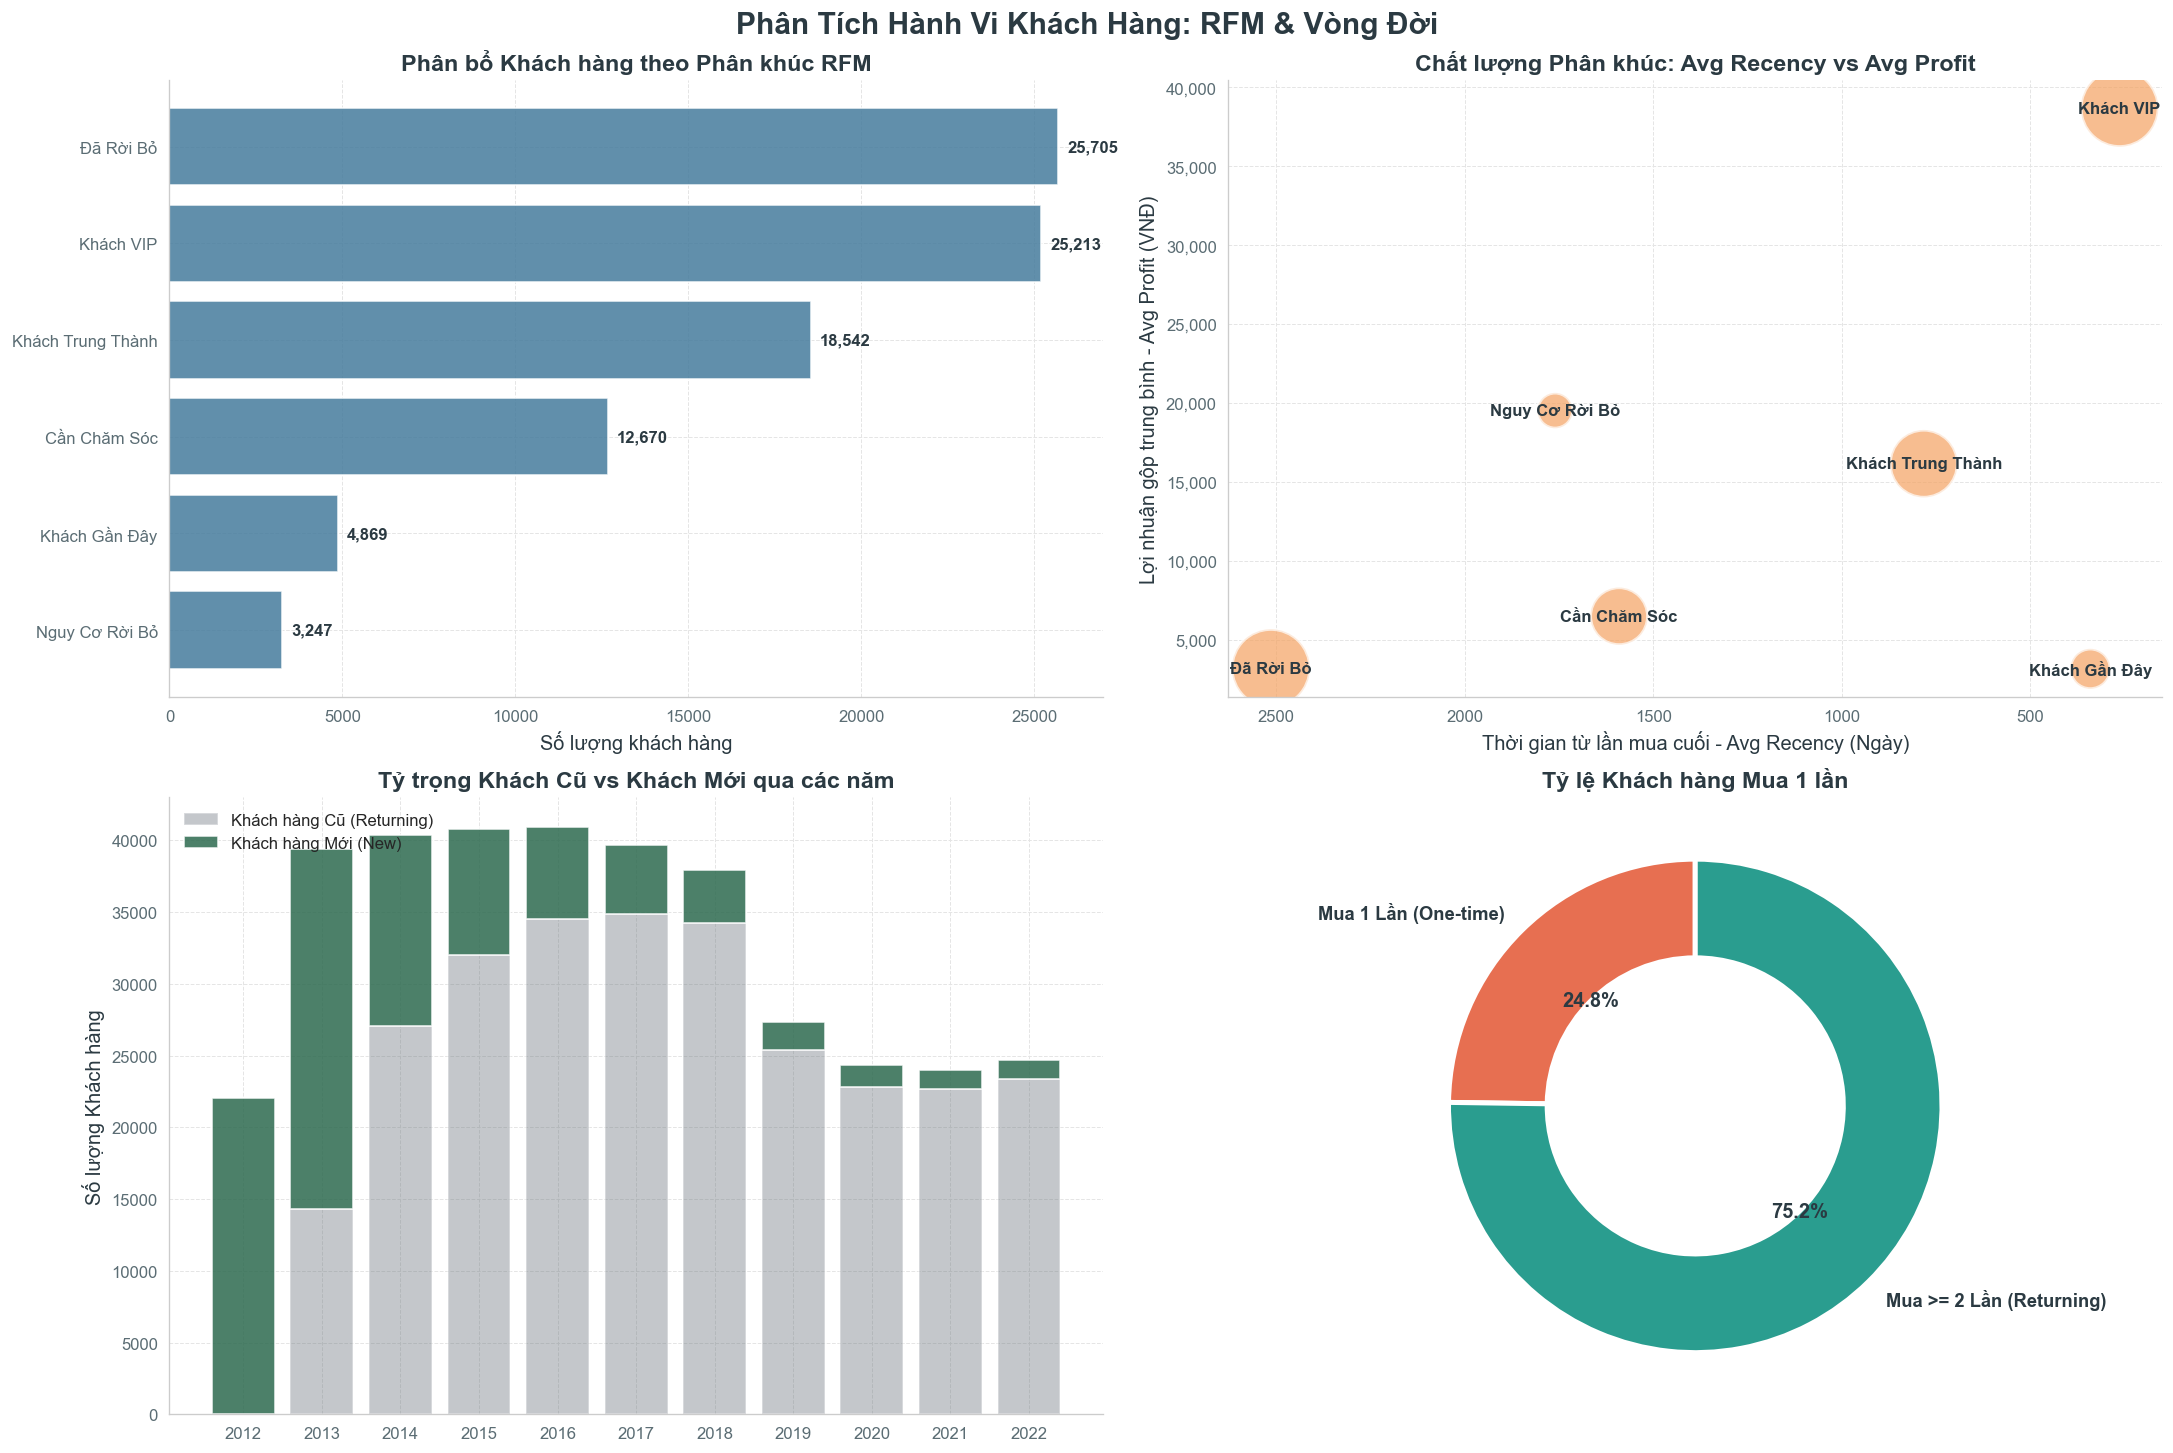

In [28]:
section_header(
    title='Phân tích khách hàng', 
    subtitle='RFM và tỷ lệ khách hàng 1 lần / khách mới - khách cũ'
)

# 1. Tính toán dữ liệu
customer_rfm = build_customer_rfm(master_df)
customer_lifecycle = compute_customer_lifecycle(master_df)

# 2. Thay thế toàn bộ print và display bằng hàm vẽ biểu đồ
plot_customer_behavior_dashboard(
    customer_rfm=customer_rfm, 
    customer_lifecycle=customer_lifecycle, 
    save_fig=True
)

Dữ liệu hành vi khách hàng hé lộ một nghịch lý chiến lược: doanh nghiệp đang làm rất tốt việc giữ chân người cũ, nhưng đang thất bại trong việc thu hút người mới.

Ở chiều tích cực, chỉ **24,8%** khách hàng rời đi sau lần mua đầu tiên — đồng nghĩa hơn **75%** quyết định quay lại. Đây là tỷ lệ giữ chân xuất sắc, phản ánh trải nghiệm sản phẩm và dịch vụ hậu mãi đang làm hài lòng phần lớn người mua. Nhóm **Khách VIP** với 25.213 người — đông thứ hai trong cơ cấu — đang là trụ cột tạo ra phần lớn lợi nhuận gộp, minh chứng cho sức mạnh của tệp khách trung thành.

Tuy nhiên, hai tín hiệu cảnh báo không thể bỏ qua. Nhóm **Đã Rời Bỏ (Lost)** hiện đông nhất với **25.705 người** — thậm chí nhiều hơn cả nhóm VIP — đặt ra câu hỏi liệu doanh nghiệp có đang dần đánh mất cả những khách từng trung thành. Nghiêm trọng hơn, **lượng khách hàng mới sụt giảm liên tục và chạm đáy trong giai đoạn 2019–2022**. Doanh nghiệp đang dựa mòn trên tệp khách cũ trong khi "dòng máu tươi" từ acquisition đang teo tóp nghiêm trọng.

Thành công trong giữ chân khách hàng là nền tảng quý giá, nhưng không thể bù đắp mãi cho sự cạn kiệt của khách mới. Nếu xu hướng này tiếp diễn, tệp khách hàng tổng thể sẽ co hẹp dần khi nhóm Lost tiếp tục phình to mà không có lực lượng mới bổ sung. Các hành động ưu tiên bao gồm tái phân bổ ngân sách marketing từ retention sang acquisition, tập trung vào phân khúc **GenZ** với chiến lược truyền thông và sản phẩm riêng, và phân tích sâu nguyên nhân rời bỏ của 25.705 khách trong nhóm Lost để xác định cơ hội cứu vãn. **Giữ chân khách cũ là phòng thủ, thu hút khách mới là tấn công — và một doanh nghiệp không thể chỉ phòng thủ mãi mà không tấn công.**

### Lợi nhuận theo Phân khúc Khách hàng

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:2081: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


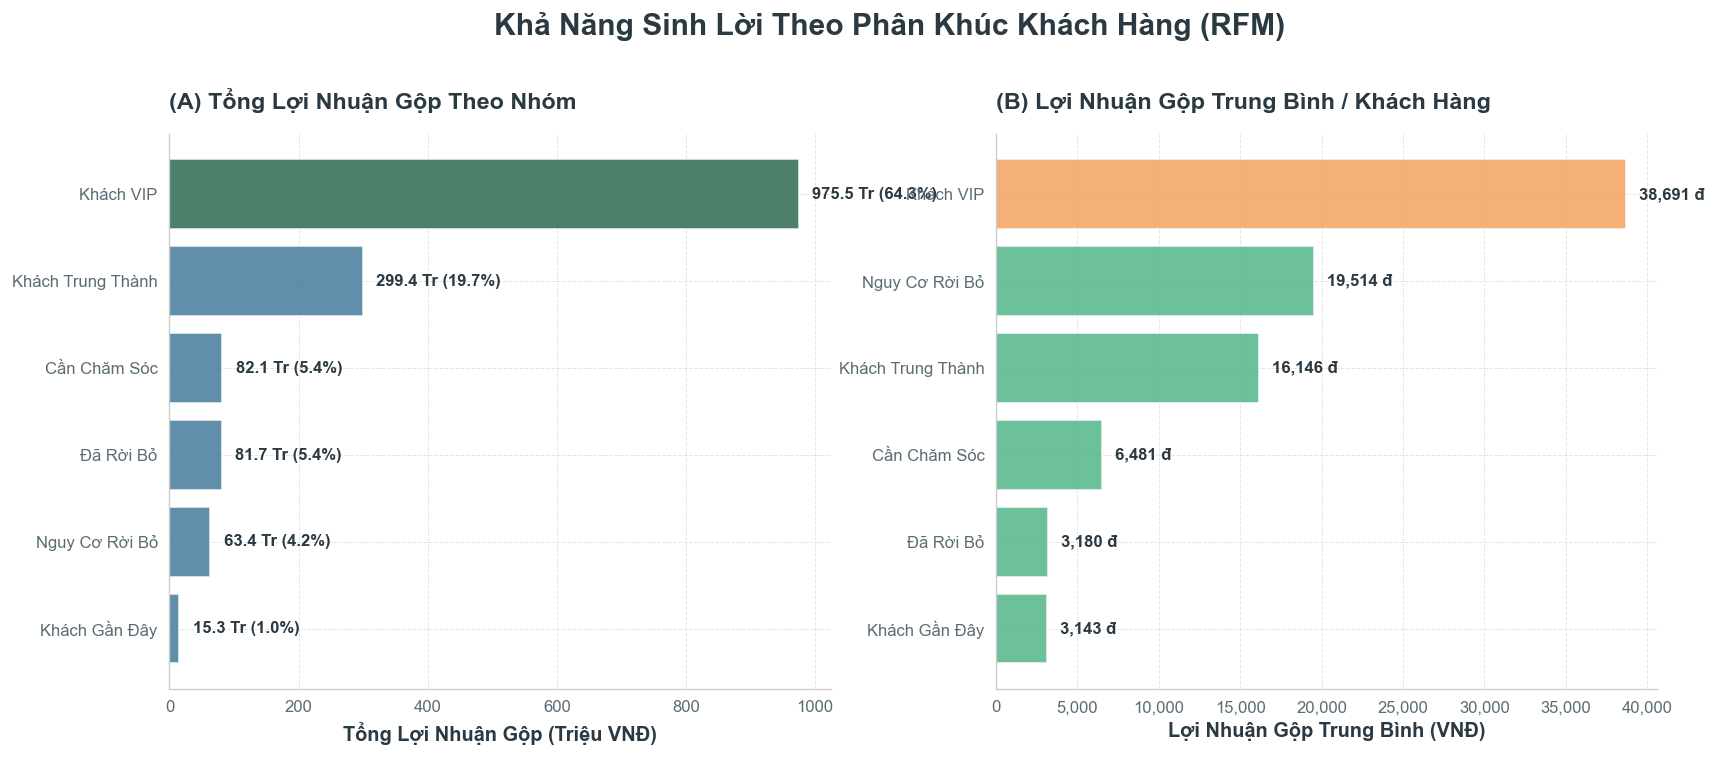

In [29]:
plot_segment_profitability(customer_rfm)

Dữ liệu xác nhận nguyên lý 80/20 một cách rõ ràng. Nhóm **Khách VIP** một mình tạo ra **975,5 triệu VNĐ**, chiếm **64,3%** tổng lợi nhuận; nhóm **Khách Thân Thiết** đóng góp thêm **299,4 triệu VNĐ**, tương đương **19,7%**. Chỉ riêng hai nhóm cốt lõi này đã mang về **84% tổng lợi nhuận toàn công ty** — thông điệp rõ ràng là tập trung nguồn lực vào chăm sóc tệp khách hàng giá trị cao sẽ mang lại ROI vượt trội hơn nhiều so với các chiến dịch mass-marketing đại chúng.

Ở đầu bên kia bảng xếp hạng, nhóm **Khách Gần Đây** chỉ đóng góp **1,0%** tổng lợi nhuận với mức trung bình **3.143 VNĐ/người** — điều hoàn toàn bình thường, bởi những giao dịch đầu tiên phải gánh toàn bộ chi phí thu hút. Nhưng chính khoảng cách lợi nhuận khổng lồ giữa nhóm Khách Gần Đây và nhóm VIP làm sáng tỏ một chân lý quan trọng: lợi nhuận không bùng nổ ở lần mua đầu tiên mà chỉ thực sự cất cánh khi doanh nghiệp thành công trong việc nuôi dưỡng khách hàng qua từng cấp độ — từ Gần Đây lên Thân Thiết, rồi lên VIP. Mỗi khách hàng rời đi trước khi đạt đến cấp Thân Thiết là một khoản đầu tư thu hút chưa kịp thu hồi.

### Xu hướng Churn & Retention theo Năm

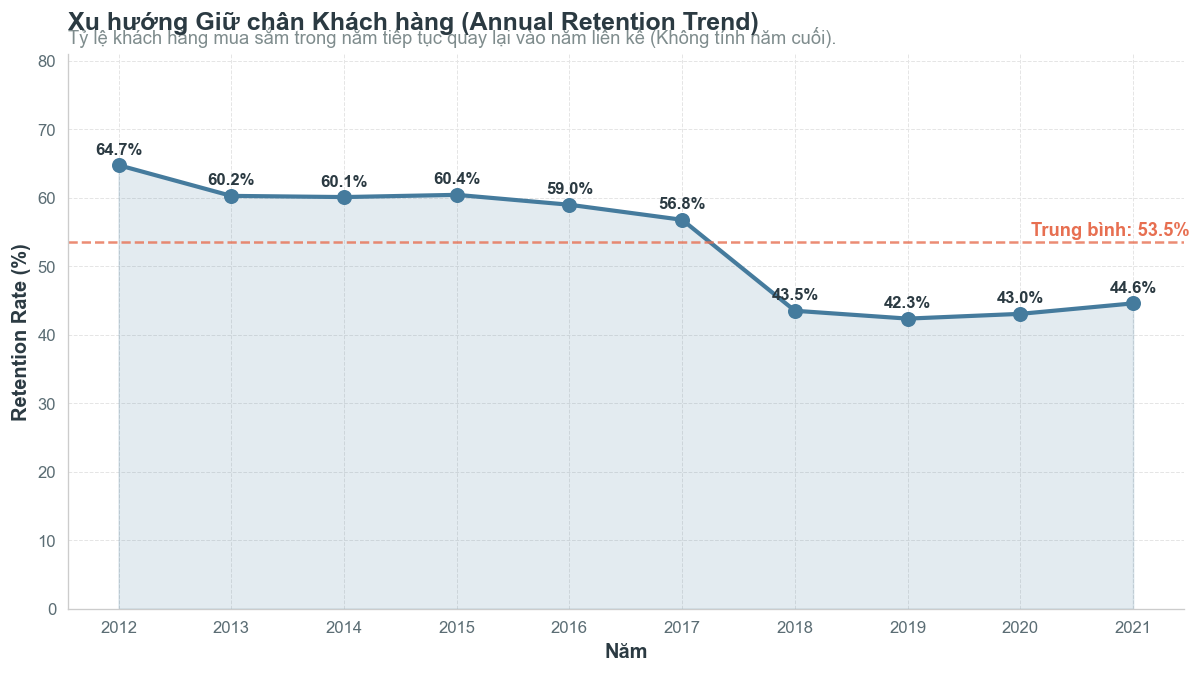

In [30]:
section_header(
    title='Phân tích Rời bỏ & Giữ chân (Churn & Retention)', 
    subtitle='Đánh giá sự ổn định của tập khách hàng và khả năng quay lại mua sắm qua các năm'
)

# Chạy hàm vẽ biểu đồ
plot_annual_retention_trend(master_df=master_df, save_fig=True)

Biểu đồ tỷ lệ giữ chân theo thời gian phơi bày một cú gãy cấu trúc rõ rệt, không phải suy giảm tự nhiên. Trong suốt 4 năm liên tiếp, doanh nghiệp duy trì tỷ lệ giữ chân luôn **trên 60%**. Chỉ trong vòng **một năm** (từ 2017 sang 2018), tỷ lệ này bốc hơi gần **14 điểm phần trăm** — và kể từ đó đến nay, **chưa bao giờ phục hồi lại được mốc 50%**. Một sự sụt giảm nhanh, sâu và kéo dài như vậy không thể lý giải bằng yếu tố thị trường thông thường; đã có một cú sốc nào đó xảy ra trong trải nghiệm khách hàng mà doanh nghiệp đến nay vẫn chưa khắc phục.

Khi đặt cạnh dữ liệu về lượng khách mới sụt giảm trầm trọng, bức tranh toàn cảnh trở nên nghiêm trọng hơn: doanh nghiệp không chỉ thất bại trong việc thu hút khách mới, mà còn đang đánh mất khả năng giữ chân tệp khách cũ. Hình ảnh trực quan nhất là một chiếc xô thủng đáy — lượng nước đổ vào (khách mới) đang teo tóp, trong khi đáy xô có lỗ thủng lớn (tỷ lệ rời bỏ gần 60%) khiến nước chảy ra ào ạt. Đổ thêm nước vào một chiếc xô thủng là vô ích.

Hành động ưu tiên số một là **sửa đáy xô trước khi đổ thêm nước**: tạm dừng chi tiêu acquisition cho đến khi khả năng giữ chân được cải thiện. Song song, cần triển khai khảo sát chuyên sâu nhắm vào nhóm khách rời bỏ sau năm 2018 để truy tìm nguyên nhân gốc rễ — bao gồm các giả thuyết về chất lượng sản phẩm, chính sách khuyến mãi và dịch vụ hậu mãi. Dựa trên kết quả đó, tái cấu trúc chương trình khách hàng thân thiết để kéo tỷ lệ giữ chân trở lại mức trên 50% — cột mốc tối thiểu để tăng trưởng bền vững.

### Mô hình Sinh tồn Khách hàng

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:1872: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(_get_survival_rate).reset_index()


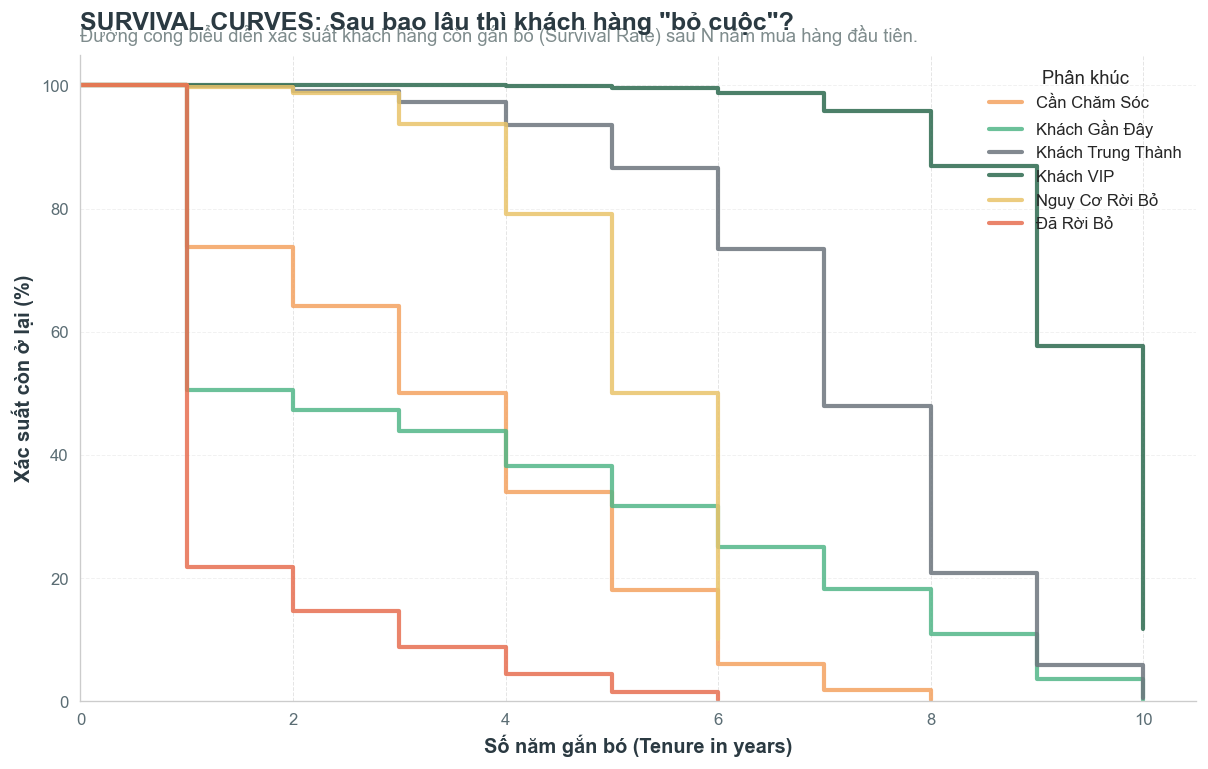

In [31]:
section_header(
    title='Phân tích Dự báo: Mô hình Sinh tồn (Survival Analysis)', 
    subtitle='Dự đoán rủi ro rời bỏ của từng phân khúc khách hàng qua các năm'
)

# Yêu cầu biến customer_rfm đã tồn tại trong môi trường từ bước trước
plot_customer_survival_analysis(
    master_df=master_df, 
    customer_rfm=customer_rfm, 
    save_fig=True
)

Mô hình sinh tồn cung cấp góc nhìn định lượng về vòng đời khách hàng theo từng phân khúc, làm rõ thêm ba bài học vận hành quan trọng.

Với nhóm Đã Rời Bỏ và Khách Gần Đây, đường cong sinh tồn lao dốc gần như thẳng đứng ngay trong năm đầu tiên. Phần lớn khách hàng phổ thông chỉ có "tuổi thọ" dưới một năm trên hệ thống; nếu doanh nghiệp không kích hoạt được họ mua đơn thứ 2 hoặc thứ 3 trong vòng 12 tháng đầu, xác suất quay lại năm thứ 2 gần như bằng 0. **12 tháng đầu tiên là cửa sổ vàng để chuyển đổi khách mới thành khách trung thành — bỏ lỡ giai đoạn này, coi như mất trắng.**

Ngược lại, nhóm Khách VIP thể hiện sức bền đáng chú ý: sau 6 năm, vẫn còn hơn 10% khách VIP tiếp tục mua hàng đều đặn. Khoảng cách lớn giữa đường cong VIP và phần còn lại chứng minh rằng lòng trung thành không tự nhiên mà có — và các chi phí bỏ ra để nuôi dưỡng nhóm này là khoản đầu tư sinh lời cao nhất trong dài hạn, khi vòng đời của họ kéo dài gấp nhiều lần khách thông thường.

Một phát hiện đáng chú ý cuối cùng: ngay cả nhóm Nguy Cơ Rời Bỏ — những khách từng mua rất nhiều — cũng đồng loạt biến mất hoàn toàn sau năm thứ 6, cho thấy tồn tại một "bức tường" vô hình ở mốc này. Doanh nghiệp cần thiết lập **"Báo động đỏ CRM" vào cuối năm thứ 5** của mỗi khách hàng và tung ra các quyền lợi đặc biệt — tặng quà hiện vật, thăng hạng vĩnh viễn, ưu đãi độc quyền — để phá vỡ "lời nguyền năm thứ 6". Những khách hàng vượt qua được cột mốc này có tiềm năng gắn bó tới 10 năm.

### Ma trận Ưu tiên Khách hàng

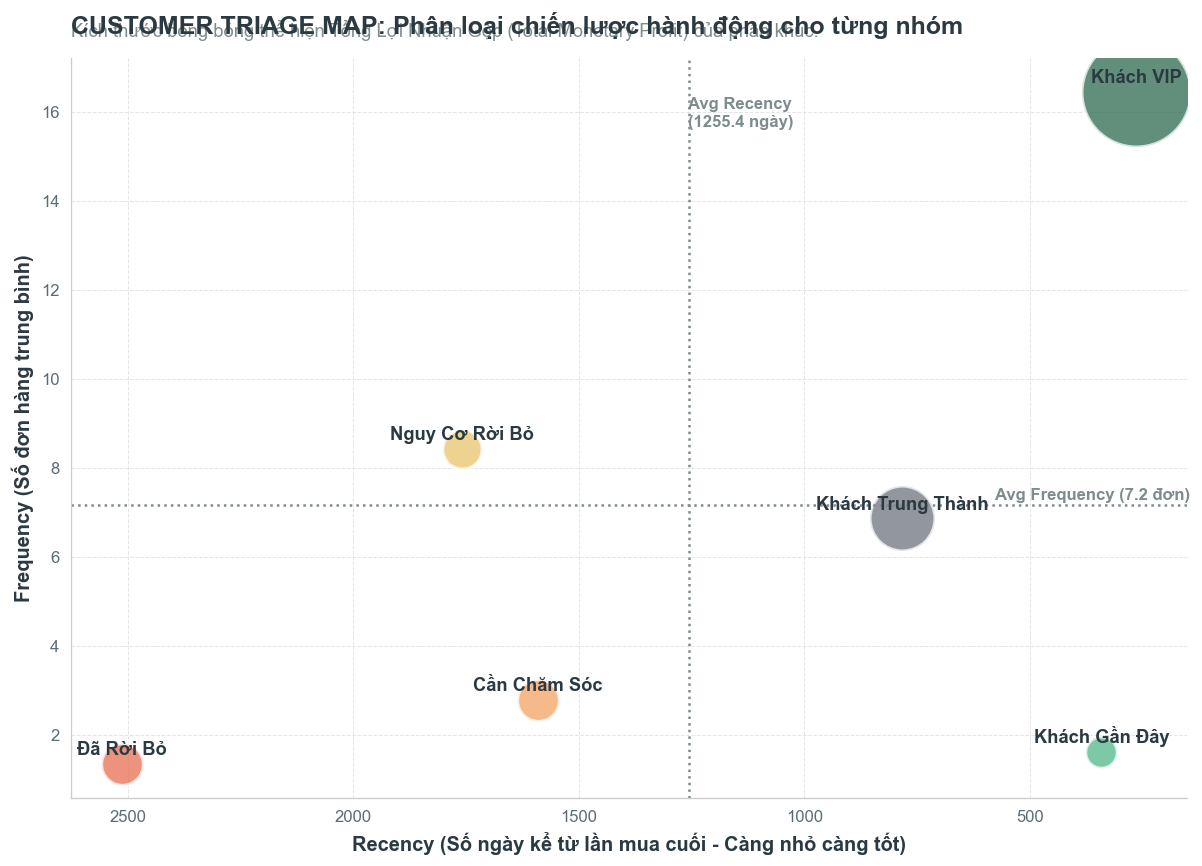

In [32]:
section_header(
    title='Ma trận Ưu tiên Khách hàng (Customer Triage Map)', 
    subtitle='Góc phần tư phía trên bên phải là nhóm Khách hàng lý tưởng. Kích thước bong bóng là Tổng Lợi nhuận.'
)

# Sử dụng dữ liệu customer_rfm đã có
plot_customer_triage_map(
    customer_rfm=customer_rfm, 
    save_fig=True
)

**Nhóm 1 — Khách VIP: Trụ cột lợi nhuận cần được bảo vệ**

Chỉ chiếm **27,9%** tổng số khách hàng nhưng tạo ra tới **64,3%** tổng lợi nhuận gộp, với tần suất mua ấn tượng (16,4 đơn/khách) và thời gian mua gần nhất tương đối ngắn (263 ngày). Thay vì dùng mã giảm giá đại trà, chiến lược đầu tư hiệu quả nhất cho nhóm này là trải nghiệm cao cấp và đặc quyền: dịch vụ CSKH riêng, quyền mua sớm các bộ sưu tập giới hạn, và chính sách miễn phí vận chuyển vô điều kiện.

**Nhóm 2 — Khách Thân Thiết: Động lực tăng trưởng tiềm năng**

Chiếm **20,5%** tệp khách hàng và đóng góp **19,7%** lợi nhuận. Tần suất mua khá tốt (6,8 đơn/khách), nhưng chỉ số Recency ở mức đáng theo dõi (782 ngày — khoảng 2 năm) cho thấy nhóm này đang có dấu hiệu giãn cách thời gian mua. Cần triển khai các chiến dịch win-back nhẹ nhàng và hệ thống gợi ý cá nhân hóa để duy trì sự gắn kết và đẩy họ lên tệp VIP trước khi họ nguội lạnh.

**Nhóm 3 — Khách Gần Đây: Tệp bản lề cần được kích hoạt**

Chiếm **5,4%** tệp khách hàng với Recency tốt (341 ngày) nhưng Frequency rất thấp (1,6 đơn/khách) và lợi nhuận mới đạt khoảng 1%. Nhiệm vụ ưu tiên là phá vỡ "lời nguyền mua 1 lần" bằng các luồng onboarding tự động và ưu đãi mạnh tay cho đơn hàng thứ 2 và thứ 3 — nhằm rèn luyện thói quen mua sắm trước khi cửa sổ 12 tháng vàng khép lại.

**Nhóm 4 — Đã Rời Bỏ & Cần Chăm Sóc: Không nên đốt ngân sách**

Hai nhóm này gộp lại chiếm hơn **42%** tệp khách hàng nhưng chỉ mang lại chưa tới **11%** lợi nhuận. Tần suất mua rất thấp và thời gian vắng mặt trung bình từ 4 đến 7 năm. Với ROI dự kiến rất thấp, không nên đầu tư ngân sách performance marketing (retargeting ads) cho tệp này; chỉ nên tiếp cận qua các kênh chi phí thấp như email xả kho cuối mùa để tối ưu hóa chi tiêu.

---
## 6. Tổng kết chiến lược & Khuyến nghị Hành động

Nhìn lại chặng đường 10 năm vận hành, dữ liệu chỉ ra rằng doanh nghiệp đang không hề gặp khó khăn trong việc thu hút lượng truy cập (traffic) hay xây dựng tệp khách hàng trung thành (nhóm VIP). Nghịch lý kìm hãm sự bứt phá và bào mòn biên lợi nhuận (hiện chỉ ở mức 9,7%) nằm ở **sự lệch pha trong phân bổ nguồn lực**. 

Để phá vỡ vòng luẩn quẩn "doanh thu đi ngang, tồn kho giam vốn, biên lợi nhuận mỏng", chiến lược của doanh nghiệp cần dịch chuyển từ "tăng trưởng bề rộng" sang "tối ưu chiều sâu" với 4 trụ cột hành động trọng tâm:

**1. Tái cấu trúc Chuỗi cung ứng ở cấp độ SKU (Giải quyết triệt để Stockout - Overstock)**
* **Vấn đề:** Doanh nghiệp đang mắc kẹt trong tình trạng vừa thiếu hàng để bán (tỷ lệ stockout 67,3%), vừa tồn ứ lượng lớn hàng hóa (overstock 76,3%). Gần 77% nguồn vốn dư thừa đang bị chôn vùi tại nhóm Streetwear, nhưng nghịch lý là nhóm này lại làm thất thoát doanh thu nhiều nhất (chiếm 80,9% thiệt hại do hết hàng).
* **Hành động:** * **Ngừng quản trị tồn kho cào bằng theo danh mục.** Cần phân tách rõ ràng đến từng cấp độ SKU: Tăng tồn kho đệm (safety stock) và rút ngắn chu kỳ nhập hàng cho các mã "vàng" thường xuyên cháy kệ (đặc biệt khi chạy promotion).
    * Kiên quyết xả kho (markdown, bán theo bundle) các SKU có vòng quay chậm (nổi cộm ở phân khúc Outdoor, Everyday) để khơi thông dòng vốn lưu động.
    * Tình trạng ứ đọng không đến từ việc khách hoàn trả hàng, mà đến từ dự báo nhu cầu sai lệch. Cần thiết lập mô hình dự báo bám sát sức mua thực tế để kiểm soát khâu thu mua đầu vào.

**2. Bịt lỗ hổng dòng tiền từ Hủy đơn & Hoàn trả**
* **Vấn đề:** Doanh thu thất thoát từ hủy đơn (1,45 tỷ VNĐ) cao gấp gần 3 lần so với chi phí hoàn hàng. Điểm rủi ro lớn nhất là phương thức thanh toán COD (tỷ lệ hủy chạm mức 16%). Đồng thời, 55% nguyên nhân hoàn hàng đến từ việc "sai kích cỡ" và "hàng lỗi" (cao nhất ở dòng sản phẩm GenZ).
* **Hành động:**
    * **Quản trị rủi ro COD:** Áp dụng ngưỡng giá trị tối đa cho các đơn hàng COD hoặc yêu cầu đặt cọc một phần đối với những đơn hàng có giá trị cao.
    * **Chuyển đổi phương thức thanh toán:** Khuyến khích khách hàng thanh toán trước thông qua chính sách chiết khấu 2-5% — mức chi phí đánh đổi này rẻ hơn rất nhiều so với tổn thất dòng tiền khi đơn bị hủy/hoàn và chi phí logistics ngược.
    * **Tối ưu rào cản mua sắm:** Chuẩn hóa lại bảng kích cỡ (size chart) cho tệp khách GenZ và tích hợp hình ảnh/review thực tế để giảm thiểu lý do hoàn hàng chủ quan.

**3. Định chuẩn lại Chiến lược Khuyến mãi (Promotion)**
* **Vấn đề:** Có đến 38,7% lượng đơn hàng đang phụ thuộc vào khuyến mãi, đây là một trong những tác nhân chính "ăn mòn" biên lợi nhuận tổng thể của doanh nghiệp.
* **Hành động:**
    * Chuyển từ "khuyến mãi đại trà để kích cầu" sang **"khuyến mãi có mục tiêu"**. Chỉ sử dụng mức chiết khấu sâu như một công cụ chiến thuật để xả hàng tồn kho chậm luân chuyển.
    * Sử dụng khuyến mãi để san phẳng tính mùa vụ: Kích cầu vào các tháng trũng (tháng 1-2, tháng 11-12) và tập trung bán nguyên giá, up-sell/cross-sell vào mùa đỉnh điểm (Quý II).

**4. Khôi phục Phương trình Tăng trưởng Khách hàng (Acquisition vs. Retention)**
* **Vấn đề:** Tỷ lệ giữ chân khách hàng (retention) rất xuất sắc, nhưng nguồn khách mới thu hút được (acquisition) đã chạm đáy từ sau 2019. Lượng khách hàng "Đã rời bỏ" (Lost) phình to vượt qua cả nhóm VIP.
* **Hành động:**
    * Triển khai khảo sát chuyên sâu vào nhóm khách rời bỏ sau năm 2018 (nhóm Lost) để tìm ra nguyên nhân gốc rễ và chặn đà suy giảm.
    * Thiết lập **"Báo động đỏ CRM"** vào cuối năm thứ 5 của mỗi khách hàng (đây là thời điểm sinh tử trước "lời nguyền rời bỏ năm thứ 6") để tung ra chiến dịch giữ chân cá nhân hóa.
    * Sau khi ổn định tỷ lệ giữ chân ở ngưỡng an toàn, cần tái khởi động và chuyển dịch ngân sách sang chiến dịch Acquisition nhằm thu hút khách hàng mới (đặc biệt là tập trung vào tệp GenZ) để bơm "dòng máu tươi" cho doanh thu.

**Thông điệp cuối cùng:**
Doanh nghiệp không thiếu khách hàng tiềm năng, không thiếu traffic, không thiếu hàng trong kho. Vấn đề nằm ở **phân bổ sai nguồn lực**: sai cơ cấu tồn kho, sai cấu hình khuyến mãi, và sai thời điểm can thiệp giữ chân khách hàng. Bốn trụ cột giải pháp trên không đòi hỏi một ngân sách đầu tư khổng lồ — chúng đòi hỏi **sự chính xác trong thực thi và kỷ luật trong đo lường**. Đây chính là chìa khóa để phá vỡ vòng luẩn quẩn "thiếu-doanh-thu-nhưng-thừa-hàng-tồn", giải phóng vốn và đưa doanh nghiệp trở lại quỹ đạo tăng trưởng lợi nhuận bền vững.